# 4주차 실습 (2) — Tensor Operations

> **텐서는 데이터와 딥러닝 사이의 공용어다. 모든 이미지, 모든 문장, 모든 그래디언트가 텐서를 통해 흐른다.**

- **Type:** Build · **Language:** Python · **Time:** ~90분
- **선수 지식:** Phase 1 Lesson 01(선형대수 직관), 02(벡터·행렬 연산)
- 원문: <https://aiengineeringfromscratch.com/lesson.html?path=phases/01-math-foundations/12-tensor-operations>

## 🎯 학습 목표 (Learning Objectives)

1. **shape · strides · reshape · transpose · 원소별 연산**을 갖춘 텐서 클래스를 밑바닥부터 구현한다.
2. **브로드캐스팅 규칙**을 적용해 모양이 다른 텐서를 **복사 없이** 연산한다.
3. **einsum** 표현식으로 내적·행렬곱·외적·배치 연산을 작성한다.
4. **멀티헤드 어텐션**의 모든 단계에서 텐서 shape을 정확히 추적한다.

---

## 📖 이 노트북을 읽는 법

> 🧸 **비유** (초등학생용) → 📐 **개념** (정확한 규칙) → 💻 **코드** (직접 증명) → 🏭 **실무** (어디에 쓰나)

| # | 주제 |
| --- | --- |
| 0 | 문제 상황 — shape 에러는 왜 딥러닝 최다 버그인가 |
| 1 | 텐서란 무엇인가 (rank · axis · shape) |
| 2 | 딥러닝에서의 텐서 shape 관례 (NCHW / NHWC) |
| 3 | 메모리 레이아웃과 strides (contiguous 문제) |
| 4 | 브로드캐스팅 규칙 |
| 5 | einsum — 만능 텐서 연산 |
| 6 | 🔨 Build It Step 1~4 — 텐서 클래스 밑바닥 구현 |
| 7 | 🔨 Build It Step 5 — NumPy 브로드캐스팅 실전 |
| 8 | 🔨 Build It Step 6 — einsum 갤러리 & 연산 비용 |
| 9 | 🔨 Build It Step 7 — einsum으로 멀티헤드 어텐션 |
| 10 | 🏭 Use It — Scratch vs NumPy vs PyTorch, 모든 레이어를 텐서 연산으로 |
| 11 | 📝 연습문제 4개 (풀이 포함) |
| 12 | 📚 용어 사전 · Ship It · 더 읽을거리 |

## 0️⃣ 문제 상황 (The Problem)

트랜스포머를 만든다. forward 패스는 깔끔해 보인다. 돌린다. 그리고:

```
RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x768 and 512x768)
```

shape을 노려본다. transpose를 넣어 본다. 이번엔:

```
Expected 4D input (got 3D input)
```

unsqueeze를 넣는다. 그러면 또 다른 게 터진다.

> **shape 에러는 딥러닝 코드에서 가장 흔한 버그다.**

개념적으로 어려운 건 아니다 — 연산마다 **shape 계약**이 있을 뿐이다. 문제는 그게 **빠르게 곱해진다**는 것. 트랜스포머 하나에 reshape·transpose·broadcast가 수십 개씩 엮여 있고, 축 하나만 틀려도 에러가 연쇄된다.

**더 나쁜 건, 어떤 shape 실수는 에러조차 내지 않는다는 것.** 엉뚱한 차원으로 브로드캐스트되거나 엉뚱한 축으로 합쳐지면서 **조용히 쓰레기 값을 만들어 낸다.**

행렬은 두 집합 사이의 관계만 다룬다. 현실 데이터는 2차원에 안 들어간다.
- 224×224 RGB 이미지 32장 배치 = **4D 텐서** `(32, 3, 224, 224)`
- 헤드 12개짜리 셀프 어텐션 = 역시 **4D** `(batch, heads, seq_len, head_dim)`

**차원 개수에 상관없이 일반화되고, 연산이 깔끔하게 합성되는 자료구조**가 필요하다. 그게 **텐서**다.

### 🧭 잠깐 — 그래서 텐서 연산으로 뭘 하려는 걸까?

텐서 연산은 “숫자를 예쁘게 정리하는 기술”이 아니라, 딥러닝 모델 안에서 데이터가 이동하는 **물류 시스템**에 가깝다.

```
이미지 32장          → (B, C, H, W)
문장 16개            → (B, T, D)
어텐션 score         → (B, heads, T, T)
선형층 가중치        → (out_features, in_features)
```

여기서 각 축은 그냥 숫자 위치가 아니라 **의미가 붙은 자리**다.

| 축 | 현실에서의 의미 |
| --- | --- |
| `B` | 한 번에 처리하는 샘플 묶음(batch) |
| `C` | 이미지 채널. 예: RGB |
| `H, W` | 이미지의 세로·가로 위치 |
| `T` | 문장 안의 토큰 위치 |
| `D` | 한 토큰을 표현하는 임베딩 좌표 |

그래서 shape을 읽는다는 건 “배열 크기 확인”이 아니라 **이 숫자가 어떤 현실 단위를 따라 움직이는지 확인하는 일**이다. 축 하나를 잘못 섞으면 모델은 에러를 내거나, 더 위험하게는 에러 없이 엉뚱한 관계를 학습한다.

> 핵심: 텐서 연산은 **의미 있는 축들을 유지·섞기·합치기·복제 없이 맞추기** 위한 언어다.



In [1]:
# ── 공통 설정 (그림의 한글 폰트 포함) ──────────────────────────────
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from functools import reduce

np.set_printoptions(precision=4, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        # 한글 폰트 + DejaVu 폴백(한글 폰트에 없는 기호용)
        matplotlib.rcParams["font.family"] = [cand, "DejaVu Sans"]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["mathtext.fontset"] = "dejavusans"
matplotlib.rcParams["figure.dpi"] = 110
print("그림 폰트:", matplotlib.rcParams["font.family"])

그림 폰트: ['Apple SD Gothic Neo', 'DejaVu Sans']


In [2]:
# 조용히 틀리는 shape 버그의 실제 사례 3가지
print("[사례 1] 에러는 나지만 원인이 안 보이는 경우")
X = np.random.randn(32, 768)
W = np.random.randn(512, 768)
try:
    X @ W
except ValueError as e:
    print("  ", e, "  <- W.T 로 써야 했다")
print("   고친 뒤 shape:", (X @ W.T).shape)

print("\n[사례 2] 에러가 안 나고 조용히 틀리는 경우 (더 위험!)")
scores = np.arange(6.0).reshape(2, 3)         # (batch=2, classes=3)
wrong = scores / scores.sum(axis=0)           # 축을 잘못 잡음: 배치 방향으로 정규화
right = scores / scores.sum(axis=1, keepdims=True)
print("   scores =\n", scores)
print("   axis=0 (틀림) 각 행의 합:", wrong.sum(axis=1), "  <- 1이 아님. 에러 없이 틀렸다")
print("   axis=1 (맞음) 각 행의 합:", right.sum(axis=1))

print("\n[사례 3] 브로드캐스팅이 '의도치 않게' 성공하는 경우")
pred   = np.array([1.0, 2.0, 3.0])            # (3,)
target = np.array([[1.0], [2.0], [3.0]])      # (3, 1)  <- 실수로 열벡터
loss_wrong = ((pred - target) ** 2).mean()
loss_right = ((pred - target.ravel()) ** 2).mean()
print("   (3,) - (3,1) ->", (pred - target).shape, " : 9개짜리 행렬이 만들어짐!")
print(f"   잘못된 loss = {loss_wrong:.4f}  /  올바른 loss = {loss_right:.4f}")

[사례 1] 에러는 나지만 원인이 안 보이는 경우
   matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 512 is different from 768)   <- W.T 로 써야 했다
   고친 뒤 shape: (32, 512)

[사례 2] 에러가 안 나고 조용히 틀리는 경우 (더 위험!)
   scores =
 [[0. 1. 2.]
 [3. 4. 5.]]
   axis=0 (틀림) 각 행의 합: [0.4857 2.5143]   <- 1이 아님. 에러 없이 틀렸다
   axis=1 (맞음) 각 행의 합: [1. 1.]

[사례 3] 브로드캐스팅이 '의도치 않게' 성공하는 경우
   (3,) - (3,1) -> (3, 3)  : 9개짜리 행렬이 만들어짐!
   잘못된 loss = 1.3333  /  올바른 loss = 0.0000


## 1️⃣ 텐서란 무엇인가

### 🧸 비유 — 서랍장

- **숫자 하나** = 사탕 한 알 → **스칼라 (rank 0)**
- **한 줄로 늘어놓기** = 사탕 한 줄 → **벡터 (rank 1)**
- **줄을 여러 개** = 사탕 상자(가로×세로) → **행렬 (rank 2)**
- **상자를 여러 층** = 서랍장 → **3D 텐서**
- **서랍장을 여러 개** = 창고 → **4D 텐서**

**"몇 단계로 나뉘어 있냐"** 가 rank, **"각 단계마다 몇 칸이냐"** 가 shape이다.

### 📐 개념

**텐서**는 **자료형이 동일한 다차원 배열**이다.

- **rank(계수) / order**: 차원의 개수
- **axis(축)**: 각 차원
- **shape(모양)**: 각 축의 크기를 나열한 튜플

```
스칼라        벡터           행렬            3D 텐서         4D 텐서
rank 0   →   rank 1    →    rank 2     →    rank 3     →    rank 4
shape ()     shape (3,)     shape (2,3)     shape (2,2,2)   shape (B,C,H,W)
```

**전체 원소 수 = 모든 크기의 곱.** shape `(2, 3, 4)`는 `2 × 3 × 4 = 24`개를 담는다.

> ⚠️ **함정:** 텐서의 `rank`는 **축의 개수**다. **행렬의 rank(계수, 일차독립 열의 수)와 완전히 다른 개념**이다.
> 행렬은 언제나 텐서 rank 2다 — 그 행렬의 계수가 1이든 100이든.

In [3]:
examples = [
    ("스칼라",   np.array(3.14)),
    ("벡터",     np.array([1., 2., 3.])),
    ("행렬",     np.array([[1., 2., 3.], [4., 5., 6.]])),
    ("3D 텐서",  np.arange(8.).reshape(2, 2, 2)),
    ("4D 텐서",  np.zeros((32, 3, 224, 224))),
]
print(f"{'이름':<10}{'rank(ndim)':>12}{'shape':>22}{'원소 수':>14}")
print("-" * 60)
for name, t in examples:
    total = int(np.prod(t.shape)) if t.shape else 1
    print(f"{name:<10}{t.ndim:>12}{str(t.shape):>22}{total:>14,}")

# 텐서 rank(축 개수) vs 행렬 rank(계수) — 완전히 다른 개념
M = np.outer([1., 2., 3.], [4., 5.])        # 외적 -> 행렬 계수는 1
print(f"\nM.shape = {M.shape}")
print(f"  텐서 rank (M.ndim)            = {M.ndim}   <- 축이 2개")
print(f"  행렬 rank (np.linalg.matrix_rank) = {np.linalg.matrix_rank(M)}   <- 일차독립 열은 1개")

이름          rank(ndim)                 shape          원소 수
------------------------------------------------------------
스칼라                  0                    ()             1
벡터                   1                  (3,)             3
행렬                   2                (2, 3)             6
3D 텐서                3             (2, 2, 2)             8
4D 텐서                4     (32, 3, 224, 224)     4,816,896

M.shape = (3, 2)
  텐서 rank (M.ndim)            = 2   <- 축이 2개
  행렬 rank (np.linalg.matrix_rank) = 1   <- 일차독립 열은 1개


### 🖼️ 그림 1 — rank 0부터 4까지

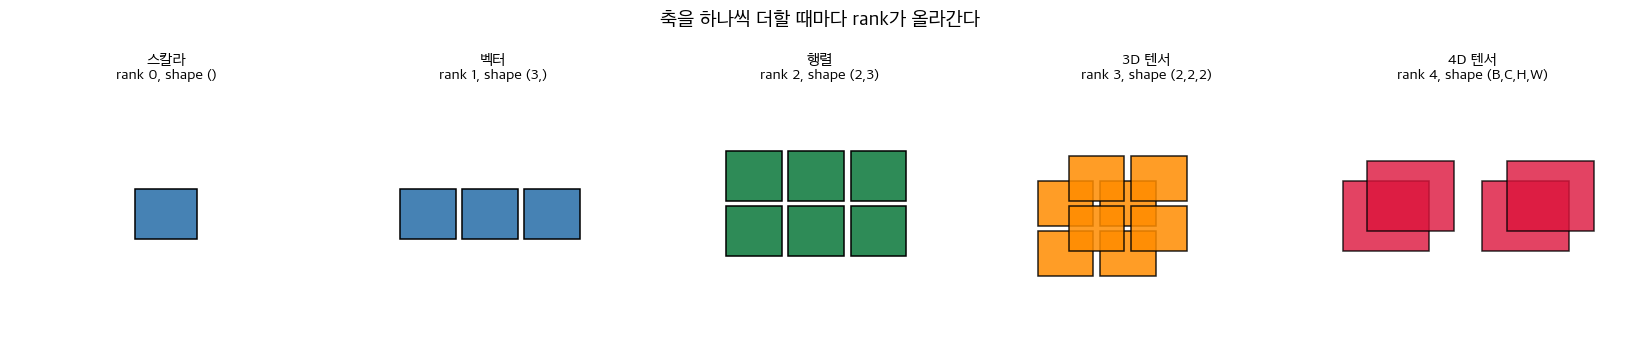

In [4]:
fig = plt.figure(figsize=(15, 3.2))

# rank 0
ax = fig.add_subplot(1, 5, 1)
ax.add_patch(plt.Rectangle((0.4, 0.4), 0.2, 0.2, fc="steelblue", ec="k"))
ax.set_title("스칼라\nrank 0, shape ()", fontsize=10); ax.axis("off")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# rank 1
ax = fig.add_subplot(1, 5, 2)
for i in range(3):
    ax.add_patch(plt.Rectangle((0.2 + i * 0.2, 0.4), 0.18, 0.2, fc="steelblue", ec="k"))
ax.set_title("벡터\nrank 1, shape (3,)", fontsize=10); ax.axis("off")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# rank 2
ax = fig.add_subplot(1, 5, 3)
for r in range(2):
    for c in range(3):
        ax.add_patch(plt.Rectangle((0.2 + c * 0.2, 0.55 - r * 0.22), 0.18, 0.2, fc="seagreen", ec="k"))
ax.set_title("행렬\nrank 2, shape (2,3)", fontsize=10); ax.axis("off")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# rank 3 (층을 어긋나게 그려 깊이 표현)
ax = fig.add_subplot(1, 5, 4)
for d in range(2):
    off = d * 0.10
    for r in range(2):
        for c in range(2):
            ax.add_patch(plt.Rectangle((0.15 + c * 0.2 + off, 0.45 - r * 0.2 + off),
                                       0.18, 0.18, fc="darkorange", ec="k", alpha=0.85))
ax.set_title("3D 텐서\nrank 3, shape (2,2,2)", fontsize=10); ax.axis("off")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# rank 4
ax = fig.add_subplot(1, 5, 5)
for b in range(2):
    for d in range(2):
        off = d * 0.08
        ax.add_patch(plt.Rectangle((0.08 + b * 0.45 + off, 0.35 + off), 0.28, 0.28,
                                   fc="crimson", ec="k", alpha=0.8))
ax.set_title("4D 텐서\nrank 4, shape (B,C,H,W)", fontsize=10); ax.axis("off")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

fig.suptitle("축을 하나씩 더할 때마다 rank가 올라간다", fontsize=13)
plt.tight_layout(); plt.show()

## 2️⃣ 딥러닝에서의 텐서 shape 관례

### 📐 개념

데이터 종류마다 shape이 **관례로 정해져 있다.**

```
[Vision]                         [NLP]
(B, C, H, W)                     (B, T, D)
 32, 3, 224, 224                  16, 128, 768
 배치, 채널, 높이, 너비             배치, 토큰 길이, 임베딩 차원

[Attention]                      [Weights]
(B, H, T, D)                     Linear   : (out, in)
 16, 12, 128, 64                 Conv2D   : (out_c, in_c, kH, kW)
 배치, 헤드, 토큰, 헤드당 차원       Embedding: (vocab, dim)
```

> ⚠️ **PyTorch는 NCHW(채널 먼저), TensorFlow 기본은 NHWC(채널 나중).**
> 레이아웃이 어긋나면 **에러가 나거나, 조용히 느려진다.**

### 🔎 shape을 읽는 법 — 숫자 튜플 말고 데이터 흐름으로 보기

예를 들어 문장 16개를 한 번에 넣고, 각 문장을 128개 토큰으로 자르고, 각 토큰을 768차원 벡터로 표현하면 shape은 이렇게 된다.

```
x.shape = (16, 128, 768)
           B    T    D
```

이건 이렇게 읽는다.

```
16개 문장 각각에 대해,
128개 토큰 각각에 대해,
768개 숫자로 그 토큰의 의미를 표현한다.
```

선형층을 지나면 보통 마지막 축 `D`만 바뀐다.

```
(B, T, D) @ (D, 4D)  →  (B, T, 4D)
```

즉, 배치 `B`와 토큰 위치 `T`는 그대로 두고, 각 토큰의 표현 좌표만 768개에서 3072개로 바꾼 것이다. 텐서 shape을 추적할 때는 항상 “어떤 축은 유지되고, 어떤 축은 섞이고, 어떤 축은 새로 생겼나?”를 본다.

> 한 줄 감각: **shape은 데이터의 주소 체계이고, 연산은 그 주소를 어떻게 바꾸는지에 대한 계약서다.**



In [5]:
B, C, H, W = 32, 3, 224, 224
T, D, Hd = 128, 768, 12

specs = [
    ("Vision  (B,C,H,W)",    (B, C, H, W),        "이미지 배치 - PyTorch NCHW"),
    ("Vision  (B,H,W,C)",    (B, H, W, C),        "이미지 배치 - TensorFlow NHWC"),
    ("NLP     (B,T,D)",      (16, T, D),          "토큰 임베딩 시퀀스"),
    ("Attn    (B,H,T,d)",    (16, Hd, T, D//Hd),  "멀티헤드 어텐션 내부"),
    ("Linear  (out,in)",     (D, D),              "선형층 가중치"),
    ("Conv2D  (o,i,kH,kW)",  (64, 3, 7, 7),       "합성곱 커널"),
    ("Embed   (vocab,dim)",  (50257, D),          "임베딩 테이블"),
]
print(f"{'용도':<22}{'shape':>26}{'원소 수':>16}{'  설명'}")
print("-" * 92)
for name, shp, desc in specs:
    print(f"{name:<22}{str(shp):>26}{int(np.prod(shp)):>16,}  {desc}")

# NCHW <-> NHWC 변환은 permute 한 줄
x_nchw = np.random.randn(2, 3, 4, 4)
x_nhwc = x_nchw.transpose(0, 2, 3, 1)
print(f"\nNCHW {x_nchw.shape}  ->  NHWC {x_nhwc.shape}")
print("데이터 값은 그대로인가:", np.allclose(x_nhwc.transpose(0, 3, 1, 2), x_nchw))
print("메모리 연속성(contiguous): NCHW =", x_nchw.flags["C_CONTIGUOUS"],
      "/ 변환 후 NHWC =", x_nhwc.flags["C_CONTIGUOUS"], " <- 변환은 '뷰'라 비연속")

용도                                         shape            원소 수  설명
--------------------------------------------------------------------------------------------
Vision  (B,C,H,W)              (32, 3, 224, 224)       4,816,896  이미지 배치 - PyTorch NCHW
Vision  (B,H,W,C)              (32, 224, 224, 3)       4,816,896  이미지 배치 - TensorFlow NHWC
NLP     (B,T,D)                   (16, 128, 768)       1,572,864  토큰 임베딩 시퀀스
Attn    (B,H,T,d)              (16, 12, 128, 64)       1,572,864  멀티헤드 어텐션 내부
Linear  (out,in)                      (768, 768)         589,824  선형층 가중치
Conv2D  (o,i,kH,kW)                (64, 3, 7, 7)           9,408  합성곱 커널
Embed   (vocab,dim)                 (50257, 768)      38,597,376  임베딩 테이블

NCHW (2, 3, 4, 4)  ->  NHWC (2, 4, 4, 3)
데이터 값은 그대로인가: True
메모리 연속성(contiguous): NCHW = True / 변환 후 NHWC = False  <- 변환은 '뷰'라 비연속


## 3️⃣ 메모리 레이아웃과 strides

### 🧸 비유 — 아파트 호수

아파트에 **101동 202호**처럼 주소가 있지만, 실제로 우편배달부에겐 **"입구에서 몇 번째 집"** 이라는 **일렬 번호**만 의미가 있다.
`(층, 호)` → 일렬 번호로 바꾸려면 **"한 층 올라가면 몇 집을 건너뛰나"** 를 알아야 한다. 그게 **stride**다.

### 📐 개념

2D 배열도 메모리에서는 **1차원 바이트 나열**이다. **strides**는 **각 축을 한 칸 이동할 때 몇 개를 건너뛰는지** 알려 준다.

```
행 우선 (Row-major, C order)      열 우선 (Column-major, F order)
  a b c d e f                       a d b e c f
  strides: (3, 1)                   strides: (1, 2)
```

shape `(3, 4)`이면 strides는 `(4, 1)` — **행을 한 칸 내려가려면 4개 건너뛰고, 열을 한 칸 가려면 1개 건너뛴다.**

```
flat_index = i * stride[0] + j * stride[1] + ...
```

> **transpose는 데이터를 옮기지 않는다.** strides만 바꿔치기한다.
> 대신 그 결과는 **비연속(non-contiguous)** 이 된다 — 한 행의 원소들이 메모리에서 더 이상 붙어 있지 않다.

In [6]:
a = np.arange(12).reshape(3, 4)
print("a =\n", a)
print("\nshape   :", a.shape)
print("strides (바이트) :", a.strides, "   원소 단위:", tuple(s // a.itemsize for s in a.strides))
print("메모리에 실제로 깔린 순서 :", a.ravel(order="K"))

# strides로 직접 인덱싱 계산해 보기
st = tuple(s // a.itemsize for s in a.strides)
flat = a.reshape(-1)
print("\n(i,j) -> flat_index = i*st[0] + j*st[1]  직접 계산")
for (i, j) in [(0, 0), (1, 2), (2, 3)]:
    idx = i * st[0] + j * st[1]
    print(f"  a[{i},{j}] = {a[i, j]}   flat[{idx}] = {flat[idx]}   일치: {a[i, j] == flat[idx]}")

# 열 우선(Fortran order)
f = np.asfortranarray(a)
print("\n열 우선(F order) 같은 배열의 strides(원소 단위):",
      tuple(s // f.itemsize for s in f.strides))
print("메모리에 깔린 순서 :", f.ravel(order="K"))

a =
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

shape   : (3, 4)
strides (바이트) : (32, 8)    원소 단위: (4, 1)
메모리에 실제로 깔린 순서 : [ 0  1  2  3  4  5  6  7  8  9 10 11]

(i,j) -> flat_index = i*st[0] + j*st[1]  직접 계산
  a[0,0] = 0   flat[0] = 0   일치: True
  a[1,2] = 6   flat[6] = 6   일치: True
  a[2,3] = 11   flat[11] = 11   일치: True

열 우선(F order) 같은 배열의 strides(원소 단위): (1, 3)
메모리에 깔린 순서 : [ 0  4  8  1  5  9  2  6 10  3  7 11]


In [7]:
# transpose는 데이터를 옮기지 않는다 -> strides만 스왑 + 비연속이 된다
aT = a.T
print("a  shape", a.shape,  "strides(원소)", tuple(s//a.itemsize for s in a.strides),
      "contiguous:", a.flags["C_CONTIGUOUS"])
print("aT shape", aT.shape, "strides(원소)", tuple(s//aT.itemsize for s in aT.strides),
      "contiguous:", aT.flags["C_CONTIGUOUS"], " <- 스트라이드만 뒤집혔다")

print("\n같은 메모리를 공유하는가:", np.shares_memory(a, aT))
aT_copy = np.ascontiguousarray(aT)          # PyTorch의 .contiguous() 에 해당
print("ascontiguousarray 후 공유:", np.shares_memory(a, aT_copy), "(복사가 일어남)")

# 비연속 텐서에서 reshape은 '조용히 복사'가 일어날 수 있다 (PyTorch의 view는 아예 실패)
print("\n비연속 배열 reshape 결과가 원본과 메모리를 공유하는가:",
      np.shares_memory(a, aT.reshape(-1)), " <- False면 복사된 것")
print("연속 배열 reshape 결과가 공유하는가:", np.shares_memory(a, a.reshape(-1)))

a  shape (3, 4) strides(원소) (4, 1) contiguous: True
aT shape (4, 3) strides(원소) (1, 4) contiguous: False  <- 스트라이드만 뒤집혔다

같은 메모리를 공유하는가: True
ascontiguousarray 후 공유: False (복사가 일어남)

비연속 배열 reshape 결과가 원본과 메모리를 공유하는가: False  <- False면 복사된 것
연속 배열 reshape 결과가 공유하는가: True


### 🖼️ 그림 2 — 같은 데이터, 다른 stride

`transpose`가 **메모리는 그대로 두고 읽는 순서만 바꾼다**는 것을 눈으로 확인한다.

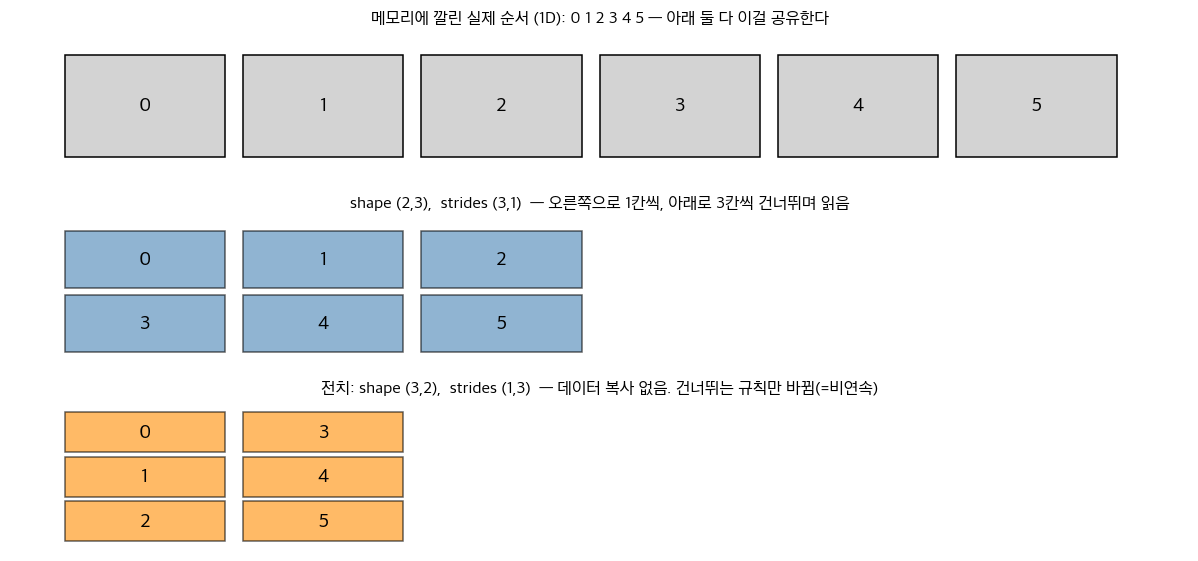

In [8]:
data = np.arange(6)
fig, axes = plt.subplots(3, 1, figsize=(11, 5.2))

# 메모리에 깔린 실제 1D 순서
ax = axes[0]
for i, v in enumerate(data):
    ax.add_patch(plt.Rectangle((i, 0), 0.9, 0.9, fc="lightgray", ec="k"))
    ax.text(i + 0.45, 0.45, str(v), ha="center", va="center", fontsize=13)
ax.set_xlim(-0.3, 6.3); ax.set_ylim(-0.2, 1.1); ax.axis("off")
ax.set_title("메모리에 깔린 실제 순서 (1D): 0 1 2 3 4 5 — 아래 둘 다 이걸 공유한다", fontsize=11)

# (2,3) 행 우선으로 읽기: strides (3,1)
ax = axes[1]
m = data.reshape(2, 3)
for r in range(2):
    for c in range(3):
        ax.add_patch(plt.Rectangle((c, 1 - r), 0.9, 0.9, fc="steelblue", ec="k", alpha=0.6))
        ax.text(c + 0.45, 1.45 - r, str(m[r, c]), ha="center", va="center", fontsize=13)
ax.set_xlim(-0.3, 6.3); ax.set_ylim(-0.2, 2.1); ax.axis("off")
ax.set_title("shape (2,3),  strides (3,1)  — 오른쪽으로 1칸씩, 아래로 3칸씩 건너뛰며 읽음", fontsize=11)

# 전치해서 (3,2)로 읽기: strides (1,3)
ax = axes[2]
mt = m.T
for r in range(3):
    for c in range(2):
        ax.add_patch(plt.Rectangle((c, 2 - r), 0.9, 0.9, fc="darkorange", ec="k", alpha=0.6))
        ax.text(c + 0.45, 2.45 - r, str(mt[r, c]), ha="center", va="center", fontsize=13)
ax.set_xlim(-0.3, 6.3); ax.set_ylim(-0.2, 3.1); ax.axis("off")
ax.set_title("전치: shape (3,2),  strides (1,3)  — 데이터 복사 없음. 건너뛰는 규칙만 바뀜(=비연속)", fontsize=11)

plt.tight_layout(); plt.show()

## 4️⃣ 브로드캐스팅 규칙

### 🧸 비유 — 도장 찍기

반 친구 30명 시험지 **전부에** 똑같은 **"참 잘했어요" 도장**을 찍고 싶다.
도장을 30개 복사할 필요 없다. **하나로 30번 찍으면 된다.**

브로드캐스팅이 딱 이거다. 편향(bias) 벡터 하나를 배치 전체에 더할 때, **벡터를 배치 크기만큼 복사하지 않는다.** 같은 값을 **읽기만 반복**한다 (메모리 절약).

### 📐 개념 — 규칙 딱 3개

1. **오른쪽부터 정렬**한다.
2. 두 차원은 **같거나, 한쪽이 1**일 때 호환된다.
3. 차원 수가 모자라면 **왼쪽에 1을 채운다**.

```
Tensor A:     (8, 1, 6, 1)
Tensor B:        (7, 1, 5)
Padded B:     (1, 7, 1, 5)     <- 왼쪽에 1 채움
Result:       (8, 7, 6, 5)     <- 각 자리에서 max(1이 아닌 쪽)
```

### 🔎 실전에서 이렇게 읽는다

가장 흔한 예시는 선형층의 bias다.

```
x    : (B, T, D)      # B개 문장, T개 토큰, D차원 표현
bias :       (D,)     # 모든 토큰에 똑같이 더할 D차원 보정값
결과 : (B, T, D)
```

`bias`는 실제로 `(B, T, D)`만큼 복사되지 않는다. NumPy/PyTorch가 “앞쪽에 `(1, 1)`이 있다고 치자”고 해석해서 같은 bias를 모든 문장·모든 토큰 위치에 반복 적용한다.

이미지 정규화도 같은 원리다.

```
image : (B, C, H, W)
mean  :    (C, 1, 1)
결과  : (B, C, H, W)
```

채널별 평균 `C`개를 배치 전체와 모든 픽셀 위치에 적용한다. 그래서 브로드캐스팅을 볼 때는 “크기 1인 축이 어느 현실 단위로 반복되는가?”를 확인하면 된다.

> 한 줄 감각: **브로드캐스팅은 작은 규칙표를 큰 데이터 전체에 복사 없이 적용하는 방법이다.**

In [9]:
def broadcast_explain(shape_a, shape_b):
    n = max(len(shape_a), len(shape_b))
    pa = (1,) * (n - len(shape_a)) + tuple(shape_a)
    pb = (1,) * (n - len(shape_b)) + tuple(shape_b)
    out, ok = [], True
    for x, y in zip(pa, pb):
        if x == y or x == 1 or y == 1:
            out.append(max(x, y))
        else:
            ok = False
            out.append(None)
    print(f"  A      : {str(tuple(shape_a)):>18}")
    print(f"  B      : {str(tuple(shape_b)):>18}")
    print(f"  A 패딩 : {str(pa):>18}")
    print(f"  B 패딩 : {str(pb):>18}")
    print(f"  결과   : {str(tuple(out)) if ok else '❌ 브로드캐스트 불가':>18}")
    return tuple(out) if ok else None

print("[원문 예시]")
res = broadcast_explain((8, 1, 6, 1), (7, 1, 5))
print("  NumPy 확인:", np.broadcast_shapes((8, 1, 6, 1), (7, 1, 5)) == res)

print("\n[실패 사례]")
broadcast_explain((3, 4), (2, 4))
try:
    np.zeros((3, 4)) + np.zeros((2, 4))
except ValueError as e:
    print("  NumPy 에러:", e)

print("\n[실무에서 매일 쓰는 패턴]")
for sa, sb, why in [((16, 128, 768), (768,),         "임베딩 배치 + bias"),
                    ((32, 3, 224, 224), (1, 3, 1, 1), "이미지 배치 * 채널별 스케일"),
                    ((3, 1), (1, 4),                  "외적/쌍별 거리")]:
    print(f"\n  {why}")
    broadcast_explain(sa, sb)

[원문 예시]
  A      :       (8, 1, 6, 1)
  B      :          (7, 1, 5)
  A 패딩 :       (8, 1, 6, 1)
  B 패딩 :       (1, 7, 1, 5)
  결과   :       (8, 7, 6, 5)
  NumPy 확인: True

[실패 사례]
  A      :             (3, 4)
  B      :             (2, 4)
  A 패딩 :             (3, 4)
  B 패딩 :             (2, 4)
  결과   :        ❌ 브로드캐스트 불가
  NumPy 에러: operands could not be broadcast together with shapes (3,4) (2,4) 

[실무에서 매일 쓰는 패턴]

  임베딩 배치 + bias
  A      :     (16, 128, 768)
  B      :             (768,)
  A 패딩 :     (16, 128, 768)
  B 패딩 :        (1, 1, 768)
  결과   :     (16, 128, 768)

  이미지 배치 * 채널별 스케일
  A      :  (32, 3, 224, 224)
  B      :       (1, 3, 1, 1)
  A 패딩 :  (32, 3, 224, 224)
  B 패딩 :       (1, 3, 1, 1)
  결과   :  (32, 3, 224, 224)

  외적/쌍별 거리
  A      :             (3, 1)
  B      :             (1, 4)
  A 패딩 :             (3, 1)
  B 패딩 :             (1, 4)
  결과   :             (3, 4)


### 🖼️ 그림 3 — 브로드캐스팅이 실제로 하는 일

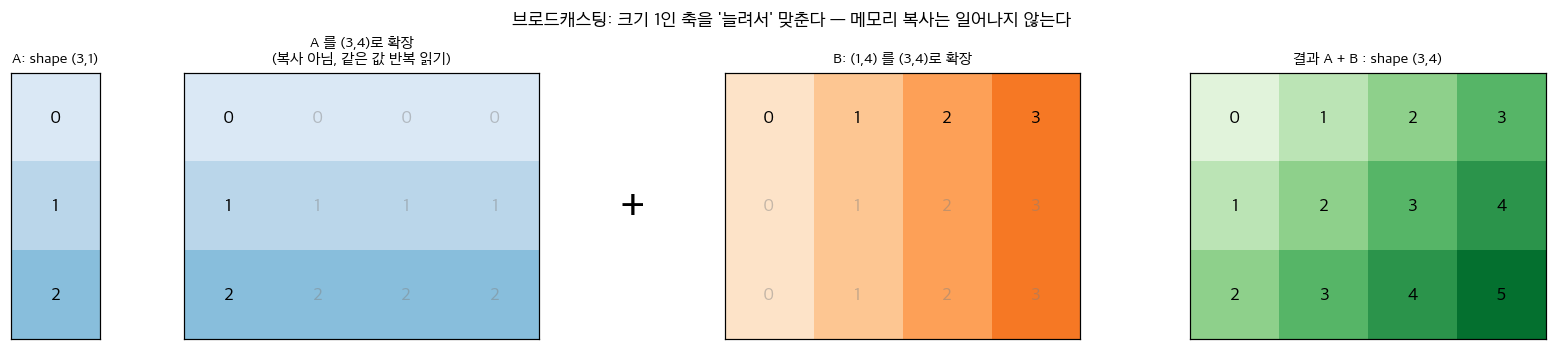

원본 8,000 바이트  ->  (1000,1000)로 확장 후에도 실제 메모리는 그대로
확장본이 원본과 메모리를 공유: True
확장본의 strides: (8, 0)  <- 두 번째 축 stride가 0! (제자리에서 반복 읽기)


In [10]:
A = np.arange(3).reshape(3, 1)          # (3,1)
Bv = np.arange(4).reshape(1, 4)         # (1,4)
R = A + Bv                              # (3,4)

fig, axes = plt.subplots(1, 5, figsize=(15, 3.2),
                         gridspec_kw={"width_ratios": [1, 3, 0.5, 3, 3.2]})

def draw(ax, M, title, cmap="Blues", ghost=None):
    M = np.atleast_2d(M)
    ax.imshow(M, cmap=cmap, vmin=-1, vmax=6)
    for (i, j), v in np.ndenumerate(M):
        faded = ghost is not None and ghost(i, j)
        ax.text(j, i, str(int(v)), ha="center", va="center", fontsize=12,
                color="gray" if faded else "black",
                alpha=0.45 if faded else 1.0)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

draw(axes[0], A, "A: shape (3,1)")
draw(axes[1], np.broadcast_to(A, (3, 4)), "A 를 (3,4)로 확장\n(복사 아님, 같은 값 반복 읽기)",
     ghost=lambda i, j: j > 0)
axes[2].text(0.5, 0.5, "+", fontsize=30, ha="center", va="center"); axes[2].axis("off")
draw(axes[3], np.broadcast_to(Bv, (3, 4)), "B: (1,4) 를 (3,4)로 확장",
     cmap="Oranges", ghost=lambda i, j: i > 0)
draw(axes[4], R, "결과 A + B : shape (3,4)", cmap="Greens")

fig.suptitle("브로드캐스팅: 크기 1인 축을 '늘려서' 맞춘다 — 메모리 복사는 일어나지 않는다", fontsize=12)
plt.tight_layout(); plt.show()

# 정말 메모리를 안 쓰는지 확인
big = np.arange(1000).reshape(1000, 1)
expanded = np.broadcast_to(big, (1000, 1000))
print(f"원본 {big.nbytes:,} 바이트  ->  (1000,1000)로 확장 후에도 실제 메모리는 그대로")
print("확장본이 원본과 메모리를 공유:", np.shares_memory(big, expanded))
print("확장본의 strides:", expanded.strides, " <- 두 번째 축 stride가 0! (제자리에서 반복 읽기)")

## 5️⃣ einsum — 만능 텐서 연산

### 🧸 비유 — 짝 맞추기 놀이

카드마다 글자가 붙어 있다. **같은 글자끼리 짝지어 곱하고**, 그 글자가 **결과에 안 적혀 있으면 다 더해서 없앤다**.

```
"ik,kj->ij"    k 는 결과에 없다 → k 로 짝지어 곱하고 전부 더한다 (= 행렬곱)
```

### 📐 개념

**아인슈타인 합 표기법(Einstein summation)** 은 각 축에 글자를 붙인다.

- **입력에는 있는데 출력에 없는 글자** → **그 축으로 합한다 (contraction)**
- **입력·출력 둘 다 있는 글자** → **그대로 유지한다**

```
matmul:  "ik,kj->ij"
   A(I,K) ──┐
            ├─ k 로 합 ─→  C(I,J)
   B(K,J) ──┘
```

**핵심 패턴 모음**

| 표현식 | 의미 |
| --- | --- |
| `i,i->` | 내적 (dot product) |
| `i,j->ij` | 외적 (outer product) |
| `ii->` | 대각합 (trace) |
| `ij->ji` | 전치 (transpose) |
| `ik,kj->ij` | 행렬곱 |
| `bij,bjk->bik` | 배치 행렬곱 |
| `bhtd,bhsd->bhts` | 어텐션 스코어 |

### 🔎 실전에서 이렇게 읽는다

`einsum`은 축 이름을 붙여서 “무엇을 유지하고, 무엇을 합칠지”를 직접 말하는 표기다.

어텐션 score를 예로 들면:

```
q : (B, H, T, D)   # 각 토큰의 query
k : (B, H, S, D)   # 비교 대상 토큰의 key

bhtd,bhsd->bhts
```

읽는 법:

```
b, h는 같은 배치와 같은 헤드라서 유지한다.
t는 query 토큰 위치라서 결과에 남긴다.
s는 key 토큰 위치라서 결과에 남긴다.
d는 query와 key를 비교하는 임베딩 좌표라서 곱한 뒤 합쳐 없앤다.
```

그래서 결과는 `(B, H, T, S)`가 된다. 의미는 “각 배치·각 헤드에서, 모든 query 토큰 `T`가 모든 key 토큰 `S`를 얼마나 바라보는가”다.

> 핵심: `einsum`에서 **화살표 오른쪽에 남는 글자 = 결과 축**, **사라지는 글자 = 합쳐지는 축**이다.

In [11]:
a = np.array([1.0, 2.0, 3.0])
b = np.array([4.0, 5.0, 6.0])
A = np.array([[1, 2], [3, 4], [5, 6]], dtype=float)   # (3,2)
Bm = np.array([[7, 8, 9], [10, 11, 12]], dtype=float) # (2,3)
Sq = np.array([[1., 2.], [3., 4.]])

print("[einsum 갤러리]  einsum 결과 == NumPy 기본 함수 결과")
print("-" * 72)
checks = [
    ("i,i->",        np.einsum("i,i->", a, b),          np.dot(a, b),        "내적"),
    ("i,j->ij",      np.einsum("i,j->ij", a, b),        np.outer(a, b),      "외적"),
    ("ii->",         np.einsum("ii->", Sq),             np.trace(Sq),        "대각합"),
    ("ii->i",        np.einsum("ii->i", Sq),            np.diag(Sq),         "대각 성분"),
    ("ij->ji",       np.einsum("ij->ji", A),            A.T,                 "전치"),
    ("ij->",         np.einsum("ij->", A),              A.sum(),             "전체 합"),
    ("ij->i",        np.einsum("ij->i", A),             A.sum(axis=1),       "행 방향 합"),
    ("ij->j",        np.einsum("ij->j", A),             A.sum(axis=0),       "열 방향 합"),
    ("ik,kj->ij",    np.einsum("ik,kj->ij", A, Bm),     A @ Bm,              "행렬곱"),
    ("ij,ij->",      np.einsum("ij,ij->", A, A),        (A * A).sum(),       "프로베니우스 내적"),
    ("ij,j->i",      np.einsum("ij,j->i", Bm, a),       Bm @ a,              "행렬 x 벡터"),
]
for expr, got, want, desc in checks:
    ok = np.allclose(got, want)
    shp = str(np.shape(got))
    print(f"{expr:<14} {desc:<16} shape {shp:<10} 일치: {ok}")

# 배치 연산
batch_A = np.random.randn(4, 3, 5)
batch_B = np.random.randn(4, 5, 2)
batch_mm = np.einsum("bij,bjk->bik", batch_A, batch_B)
print(f"\nbij,bjk->bik  배치 행렬곱  {batch_A.shape} x {batch_B.shape} -> {batch_mm.shape}")
print("np.matmul 과 일치:", np.allclose(batch_mm, batch_A @ batch_B))

[einsum 갤러리]  einsum 결과 == NumPy 기본 함수 결과
------------------------------------------------------------------------
i,i->          내적               shape ()         일치: True
i,j->ij        외적               shape (3, 3)     일치: True
ii->           대각합              shape ()         일치: True
ii->i          대각 성분            shape (2,)       일치: True
ij->ji         전치               shape (2, 3)     일치: True
ij->           전체 합             shape ()         일치: True
ij->i          행 방향 합           shape (3,)       일치: True
ij->j          열 방향 합           shape (2,)       일치: True
ik,kj->ij      행렬곱              shape (3, 3)     일치: True
ij,ij->        프로베니우스 내적        shape ()         일치: True
ij,j->i        행렬 x 벡터          shape (2,)       일치: True

bij,bjk->bik  배치 행렬곱  (4, 3, 5) x (4, 5, 2) -> (4, 3, 2)
np.matmul 과 일치: True


### 📐 einsum의 연산 비용

**축약(contraction)의 계산 비용은 등장하는 모든 인덱스 크기의 곱**이다 (유지되는 축 + 합쳐지는 축 전부).

```
bij,bjk->bik  에서  B=32, I=128, J=64, K=128 이면
32 * 128 * 64 * 128 = 33,554,432 번의 곱셈-덧셈
```

In [12]:
B_, I_, J_, K_ = 32, 128, 64, 128
cost = B_ * I_ * J_ * K_
print(f"bij,bjk->bik  (B={B_}, I={I_}, J={J_}, K={K_})")
print(f"  비용 = {B_} * {I_} * {J_} * {K_} = {cost:,} 번의 곱셈-덧셈")

# 실제로 세어 보기: 출력 원소 수 x 축약 축 길이
out_elems = B_ * I_ * K_
print(f"  검산: 출력 원소 {out_elems:,}개 x 각 원소당 j 루프 {J_}회 = {out_elems * J_:,}")

print("\n[축약 순서가 비용을 좌우한다]")
n = 100
X = np.random.randn(n, n); Y = np.random.randn(n, n); Z = np.random.randn(n, 1)
print("  (X @ Y) @ Z : ", f"{n*n*n + n*n*1:,} 연산")
print("  X @ (Y @ Z) : ", f"{n*n*1 + n*n*1:,} 연산   <- 훨씬 싸다")
path, info = np.einsum_path("ij,jk,kl->il", X, Y, Z, optimize="optimal")
print("\n  np.einsum_path가 고른 축약 순서:", path)
for line in info.strip().splitlines():
    line = line.strip()
    if line.startswith(("Complete contraction", "Naive FLOP", "Optimized FLOP", "Speedup")):
        print("   ", line)
print("  결과 일치:", np.allclose(np.einsum("ij,jk,kl->il", X, Y, Z, optimize=True), X @ Y @ Z))

bij,bjk->bik  (B=32, I=128, J=64, K=128)
  비용 = 32 * 128 * 64 * 128 = 33,554,432 번의 곱셈-덧셈
  검산: 출력 원소 524,288개 x 각 원소당 j 루프 64회 = 33,554,432

[축약 순서가 비용을 좌우한다]
  (X @ Y) @ Z :  1,010,000 연산
  X @ (Y @ Z) :  20,000 연산   <- 훨씬 싸다

  np.einsum_path가 고른 축약 순서: ['einsum_path', (1, 2), (0, 1)]
    Complete contraction:  ij,jk,kl->il
    Naive FLOP count:  3.000e+06
    Optimized FLOP count:  4.000e+04
  결과 일치: True


## 6️⃣ 🔨 Build It — 텐서 클래스 밑바닥 구현

원문의 `code/tensors.py`에 해당하는 부분을 직접 만든다.

### Step 1 — 저장소(storage)와 strides

텐서는 **평평한 숫자 리스트 + shape 메타데이터**를 저장한다. strides는 다차원 인덱스를 평평한 위치로 옮기는 방법을 알려 준다.

shape `(3, 4)`의 strides는 `(4, 1)` — **행 하나 내려가려면 4칸, 열 하나 가려면 1칸.**

In [13]:
class Tensor:
    def __init__(self, data, shape=None):
        if isinstance(data, (list, tuple)):
            self._data, self._shape = self._flatten_nested(data)
        elif isinstance(data, np.ndarray):
            self._data = data.flatten().tolist()
            self._shape = tuple(data.shape)
        else:
            self._data = [data]
            self._shape = ()

        if shape is not None:
            total = reduce(lambda a, b: a * b, shape, 1)
            if total != len(self._data):
                raise ValueError(
                    f"Cannot reshape {len(self._data)} elements into shape {shape}"
                )
            self._shape = tuple(shape)

        self._strides = self._compute_strides(self._shape)

    # ---- 메타데이터 -------------------------------------------------
    @staticmethod
    def _compute_strides(shape):
        if len(shape) == 0:
            return ()
        strides = [1] * len(shape)
        for i in range(len(shape) - 2, -1, -1):
            strides[i] = strides[i + 1] * shape[i + 1]
        return tuple(strides)

    @staticmethod
    def _flatten_nested(data):
        shape = []
        probe = data
        while isinstance(probe, (list, tuple)):
            shape.append(len(probe))
            probe = probe[0] if len(probe) else None
        flat = []
        def rec(x):
            if isinstance(x, (list, tuple)):
                for e in x:
                    rec(e)
            else:
                flat.append(x)
        rec(data)
        return flat, tuple(shape)

    @property
    def shape(self):   return self._shape
    @property
    def strides(self): return self._strides
    @property
    def ndim(self):    return len(self._shape)
    @property
    def size(self):    return len(self._data)
    @property
    def data(self):    return list(self._data)

    def __repr__(self):
        return f"Tensor(shape={self._shape}, strides={self._strides}, data={self._data})"

    # ---- 인덱싱 -----------------------------------------------------
    def _flat_index(self, idx):
        if not isinstance(idx, tuple):
            idx = (idx,)
        if len(idx) != self.ndim:
            raise IndexError(f"{self.ndim}개 인덱스가 필요한데 {len(idx)}개가 왔다")
        pos = 0
        for i, (k, s, dim) in enumerate(zip(idx, self._strides, self._shape)):
            if not (-dim <= k < dim):
                raise IndexError(f"축 {i}의 인덱스 {k}가 범위(0~{dim-1})를 벗어남")
            pos += (k % dim) * s
        return pos

    def __getitem__(self, idx): return self._data[self._flat_index(idx)]
    def __setitem__(self, idx, v): self._data[self._flat_index(idx)] = v

    def to_numpy(self):
        return np.array(self._data).reshape(self._shape) if self._shape else np.array(self._data[0])


t = Tensor(list(range(12)), shape=(3, 4))
print(t)
print("\nshape (3,4) 의 strides =", t.strides, " <- 행 한 칸 = 4개 건너뛰기")
print("t[2,3] =", t[2, 3], "  (flat 위치 2*4 + 3 = 11)")
print("NumPy와 일치:", np.array_equal(t.to_numpy(), np.arange(12).reshape(3, 4)))

t3 = Tensor(list(range(24)), shape=(2, 3, 4))
print("\nshape (2,3,4) 의 strides =", t3.strides, " <- (12, 4, 1)")
print("t3[1,2,3] =", t3[1, 2, 3], " (flat 1*12 + 2*4 + 3 = 23)")

Tensor(shape=(3, 4), strides=(4, 1), data=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])

shape (3,4) 의 strides = (4, 1)  <- 행 한 칸 = 4개 건너뛰기
t[2,3] = 11   (flat 위치 2*4 + 3 = 11)
NumPy와 일치: True

shape (2,3,4) 의 strides = (12, 4, 1)  <- (12, 4, 1)
t3[1,2,3] = 23  (flat 1*12 + 2*4 + 3 = 23)


### Step 2 — reshape, squeeze, unsqueeze

**reshape**은 원소 순서를 바꾸지 않고 shape만 바꾼다. 전체 원소 수는 그대로여야 한다. 한 차원에 `-1`을 쓰면 자동으로 크기를 추론한다.

**squeeze**는 크기 1인 축을 제거하고, **unsqueeze**는 크기 1인 축을 삽입한다.

> unsqueeze는 브로드캐스팅에 결정적이다 — bias 벡터 `(D,)` 를 배치 `(B, T, D)` 에 더하려면 `(1, 1, D)`로 unsqueeze가 필요하다.

In [14]:
def _reshape(self, new_shape):
    new_shape = tuple(new_shape)
    if -1 in new_shape:
        if new_shape.count(-1) > 1:
            raise ValueError("-1 은 한 번만 쓸 수 있다")
        known = reduce(lambda a, b: a * b, [d for d in new_shape if d != -1], 1)
        if self.size % known != 0:
            raise ValueError(f"{self.size}개를 {new_shape}로 나눌 수 없다")
        new_shape = tuple(self.size // known if d == -1 else d for d in new_shape)
    return Tensor(self.data, shape=new_shape)

def _squeeze(self, axis=None):
    if axis is None:
        new = tuple(d for d in self._shape if d != 1)
    else:
        axis = axis % self.ndim
        if self._shape[axis] != 1:
            raise ValueError(f"축 {axis}의 크기가 1이 아니라 {self._shape[axis]}")
        new = self._shape[:axis] + self._shape[axis + 1:]
    return Tensor(self.data, shape=new if new else (1,))

def _unsqueeze(self, axis):
    axis = axis if axis >= 0 else axis + self.ndim + 1
    new = self._shape[:axis] + (1,) + self._shape[axis:]
    return Tensor(self.data, shape=new)

Tensor.reshape, Tensor.squeeze, Tensor.unsqueeze = _reshape, _squeeze, _unsqueeze

t = Tensor(list(range(12)), shape=(2, 6))
print("원본        :", t.shape, t.data)
print("reshape(3,4):", t.reshape((3, 4)).shape, t.reshape((3, 4)).data)
print("reshape(-1,3):", t.reshape((-1, 3)).shape, " <- -1 이 4로 추론됨")

t = Tensor(list(range(6)), shape=(1, 3, 1, 2))
print("\nsqueeze 전 :", t.shape)
print("squeeze()  :", t.squeeze().shape, " <- 크기 1인 축이 모두 사라짐")
print("squeeze(0) :", t.squeeze(0).shape, " <- 0번 축만")

v = Tensor([1, 2, 3])
print("\nunsqueeze 전 :", v.shape)
print("unsqueeze(0) :", v.unsqueeze(0).shape, " (배치 축 추가)")
print("unsqueeze(1) :", v.unsqueeze(1).shape, " (열벡터로)")
print("unsqueeze(-1):", v.unsqueeze(-1).shape)

# 실무 패턴: bias (D,) 를 (B,T,D) 에 더하려면 (1,1,D) 로
bias = Tensor([0.1, 0.2, 0.3])
print("\nbias", bias.shape, "-> unsqueeze 두 번 ->",
      bias.unsqueeze(0).unsqueeze(0).shape, " : (B,T,D) 와 브로드캐스트 가능")

원본        : (2, 6) [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
reshape(3,4): (3, 4) [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
reshape(-1,3): (4, 3)  <- -1 이 4로 추론됨

squeeze 전 : (1, 3, 1, 2)
squeeze()  : (3, 2)  <- 크기 1인 축이 모두 사라짐
squeeze(0) : (3, 1, 2)  <- 0번 축만

unsqueeze 전 : (3,)
unsqueeze(0) : (1, 3)  (배치 축 추가)
unsqueeze(1) : (3, 1)  (열벡터로)
unsqueeze(-1): (3, 1)

bias (3,) -> unsqueeze 두 번 -> (1, 1, 3)  : (B,T,D) 와 브로드캐스트 가능


### Step 3 — transpose와 permute

**transpose**는 두 축을 바꾸고, **permute**는 모든 축을 재배열한다. NCHW ↔ NHWC 변환이 바로 이것이다.

> ⚠️ transpose/permute 이후 텐서는 **메모리에서 비연속**이 된다.
> PyTorch에서는 비연속 텐서에 `view`가 **실패**한다 — `reshape`를 쓰거나 먼저 `.contiguous()`를 호출해야 한다.

In [15]:
def _permute(self, dims):
    dims = tuple(d % self.ndim for d in dims)
    if sorted(dims) != list(range(self.ndim)):
        raise ValueError(f"dims {dims} 는 축 {tuple(range(self.ndim))} 의 순열이어야 한다")
    new_shape = tuple(self._shape[d] for d in dims)
    new_strides = tuple(self._strides[d] for d in dims)   # strides만 재배열!

    out = [0] * self.size
    def rec(axis, idx):
        if axis == len(new_shape):
            src = sum(i * s for i, s in zip(idx, new_strides))   # 원본 메모리 위치
            dst = 0
            for i, d in zip(idx, Tensor._compute_strides(new_shape)):
                dst += i * d
            out[dst] = self._data[src]
            return
        for i in range(new_shape[axis]):
            rec(axis + 1, idx + (i,))
    rec(0, ())
    return Tensor(out, shape=new_shape)

def _transpose(self, a, b):
    dims = list(range(self.ndim))
    dims[a], dims[b] = dims[b], dims[a]
    return self.permute(dims)

Tensor.permute, Tensor.transpose = _permute, _transpose

mat = Tensor(list(range(6)), shape=(2, 3))
tr = mat.transpose(0, 1)
print("원본 (2,3):", mat.data, " strides", mat.strides)
print("전치 (3,2):", tr.data, "  strides", tr.strides)
print("NumPy와 일치:", np.array_equal(tr.to_numpy(), np.arange(6).reshape(2, 3).T))

t4d = Tensor(list(range(24)), shape=(1, 2, 3, 4))
perm = t4d.permute((0, 2, 3, 1))         # NCHW -> NHWC
print(f"\nNCHW {t4d.shape}  --permute(0,2,3,1)-->  NHWC {perm.shape}")
print("NumPy와 일치:",
      np.array_equal(perm.to_numpy(), np.arange(24).reshape(1, 2, 3, 4).transpose(0, 2, 3, 1)))

# strides 관점: 전치는 스트라이드 스왑
print(f"\n원본 strides {t4d.strides}  ->  permute 후 논리적 strides "
      f"{tuple(t4d.strides[d] for d in (0,2,3,1))}")
print("(우리 구현은 실제 재배열까지 하지만, NumPy/PyTorch는 strides만 바꾸고 데이터는 그대로 둔다)")

원본 (2,3): [0, 1, 2, 3, 4, 5]  strides (3, 1)
전치 (3,2): [0, 3, 1, 4, 2, 5]   strides (2, 1)
NumPy와 일치: True

NCHW (1, 2, 3, 4)  --permute(0,2,3,1)-->  NHWC (1, 3, 4, 2)
NumPy와 일치: True

원본 strides (24, 12, 4, 1)  ->  permute 후 논리적 strides (24, 4, 1, 12)
(우리 구현은 실제 재배열까지 하지만, NumPy/PyTorch는 strides만 바꾸고 데이터는 그대로 둔다)


### Step 4 — 원소별 연산과 축소(reduction)

**원소별 연산**(더하기·곱하기·빼기)은 각 원소에 독립적으로 적용되며 shape이 유지된다.
**축소 연산**(sum·mean·max)은 하나 이상의 축을 없앤다.

실무 예:
- CNN의 **전역 평균 풀링**: `(B, C, H, W).mean(axis=[2, 3])` → `(B, C)`
- NLP의 **시퀀스 평균 풀링**: `(B, T, D).mean(axis=1)` → `(B, D)`

In [16]:
def _elementwise_op(self, other, op):
    if isinstance(other, Tensor):
        if self._shape != other._shape:
            raise ValueError(f"shape 불일치: {self._shape} vs {other._shape}")
        vals = [op(x, y) for x, y in zip(self._data, other._data)]
    else:
        vals = [op(x, other) for x in self._data]
    return Tensor(vals, shape=self._shape)

Tensor.__add__ = lambda s, o: _elementwise_op(s, o, lambda a, b: a + b)
Tensor.__sub__ = lambda s, o: _elementwise_op(s, o, lambda a, b: a - b)
Tensor.__mul__ = lambda s, o: _elementwise_op(s, o, lambda a, b: a * b)

def _reduce(self, axis=None, how="sum"):
    arr = self.to_numpy()
    fn = {"sum": np.sum, "mean": np.mean, "max": np.max}[how]
    out = fn(arr) if axis is None else fn(arr, axis=axis)
    return Tensor(np.atleast_1d(out), shape=np.shape(out) if np.shape(out) else (1,))

Tensor.sum  = lambda s, axis=None: _reduce(s, axis, "sum")
Tensor.mean = lambda s, axis=None: _reduce(s, axis, "mean")
Tensor.max  = lambda s, axis=None: _reduce(s, axis, "max")

a = Tensor([[1, 2], [3, 4]])
b = Tensor([[10, 20], [30, 40]])
print("a + b      :", (a + b).data, " shape", (a + b).shape)
print("a * 2      :", (a * 2).data)
print("b - a      :", (b - a).data)
print("a.sum(0)   :", a.sum(axis=0).data, " <- 열 방향(행이 사라짐)")
print("a.sum(1)   :", a.sum(axis=1).data, " <- 행 방향")
print("a.sum()    :", a.sum().data)

print("\n[실무 축소 패턴]")
feat = np.random.randn(8, 64, 7, 7)             # (B, C, H, W)
gap = feat.mean(axis=(2, 3))
print(f"  CNN 전역 평균 풀링 : {feat.shape} --mean(axis=(2,3))--> {gap.shape}")
seq = np.random.randn(16, 128, 768)             # (B, T, D)
pooled = seq.mean(axis=1)
print(f"  NLP 시퀀스 평균 풀링: {seq.shape} --mean(axis=1)--> {pooled.shape}")
logits = np.random.randn(4, 10)
print(f"  분류 argmax        : {logits.shape} --argmax(axis=1)--> {logits.argmax(axis=1).shape}")

a + b      : [11, 22, 33, 44]  shape (2, 2)
a * 2      : [2, 4, 6, 8]
b - a      : [9, 18, 27, 36]
a.sum(0)   : [4, 6]  <- 열 방향(행이 사라짐)
a.sum(1)   : [3, 7]  <- 행 방향
a.sum()    : [10]

[실무 축소 패턴]
  CNN 전역 평균 풀링 : (8, 64, 7, 7) --mean(axis=(2,3))--> (8, 64)
  NLP 시퀀스 평균 풀링: (16, 128, 768) --mean(axis=1)--> (16, 768)
  분류 argmax        : (4, 10) --argmax(axis=1)--> (4,)


## 7️⃣ 🔨 Build It Step 5 — NumPy 브로드캐스팅 실전

원문 `demo_broadcasting_numpy()` 의 핵심 패턴들이다.

In [17]:
# 1) 활성값 + bias : (4,3) + (3,) -> (4,3)
activations = np.random.randn(4, 3)
bias = np.array([0.1, 0.2, 0.3])
result = activations + bias
print(f"1) 활성값 + bias : {activations.shape} + {bias.shape} -> {result.shape}")
print("   각 행마다 같은 bias가 더해졌는가:",
      np.allclose(result - activations, np.tile(bias, (4, 1))))

# 2) 이미지 배치 * 채널별 스케일 : (2,3,4,4) * (1,3,1,1)
images = np.random.randn(2, 3, 4, 4)
scale = np.array([0.5, 1.0, 1.5]).reshape(1, 3, 1, 1)
result = images * scale
print(f"\n2) 채널별 스케일 : {images.shape} * {scale.shape} -> {result.shape}")
print("   1번 채널이 0.5배 됐는가:", np.allclose(result[:, 0], images[:, 0] * 0.5))

# 3) 외적 : (3,1) * (1,4) -> (3,4)
a = np.array([1, 2, 3]).reshape(-1, 1)
b = np.array([10, 20, 30, 40]).reshape(1, -1)
outer = a * b
print(f"\n3) 외적 : {a.shape} * {b.shape} -> {outer.shape}")
print(outer)
print("   np.outer 와 일치:", np.allclose(outer, np.outer(a.ravel(), b.ravel())))

1) 활성값 + bias : (4, 3) + (3,) -> (4, 3)
   각 행마다 같은 bias가 더해졌는가: True

2) 채널별 스케일 : (2, 3, 4, 4) * (1, 3, 1, 1) -> (2, 3, 4, 4)
   1번 채널이 0.5배 됐는가: True

3) 외적 : (3, 1) * (1, 4) -> (3, 4)
[[ 10  20  30  40]
 [ 20  40  60  80]
 [ 30  60  90 120]]
   np.outer 와 일치: True


### 브로드캐스팅으로 쌍별 거리(pairwise distance) 계산

`(M, 2)` 를 `(M, 1, 2)` 로, `(N, 2)` 를 `(1, N, 2)` 로 reshape하고 → 빼고 → 제곱하고 → 마지막 축으로 합하고 → 제곱근. 결과는 `(M, N)`.

이건 **kNN, k-means, 검색, 추천**의 심장부에서 매일 도는 연산이다.

In [18]:
M_pts = np.array([[0., 0.], [1., 0.], [0., 2.]])      # (3, 2)
N_pts = np.array([[0., 0.], [3., 4.], [1., 1.], [0., 2.]])  # (4, 2)

diff = M_pts[:, None, :] - N_pts[None, :, :]          # (3,1,2) - (1,4,2) -> (3,4,2)
dist = np.sqrt((diff ** 2).sum(axis=-1))              # (3,4)

print(f"({M_pts.shape}) 와 ({N_pts.shape}) -> 중간 diff {diff.shape} -> 거리 {dist.shape}")
print("\n거리 행렬:\n", dist)

# 이중 루프와 비교해 정확성 확인
naive = np.array([[np.linalg.norm(p - q) for q in N_pts] for p in M_pts])
print("\n이중 루프 결과와 일치:", np.allclose(dist, naive))

# 각 M 점의 최근접 N 점
nn = dist.argmin(axis=1)
print("\n각 점의 최근접 이웃 인덱스:", nn, " 거리:", np.round(dist[np.arange(3), nn], 4))

# 속도 비교
import time
P = np.random.randn(400, 16); Q = np.random.randn(400, 16)
t0 = time.perf_counter()
D_bc = np.sqrt(((P[:, None, :] - Q[None, :, :]) ** 2).sum(-1))
t_bc = time.perf_counter() - t0
t0 = time.perf_counter()
D_loop = np.empty((400, 400))
for i in range(400):
    for j in range(400):
        D_loop[i, j] = np.linalg.norm(P[i] - Q[j])
t_loop = time.perf_counter() - t0
print(f"\n브로드캐스팅 {t_bc*1000:.2f} ms  vs  이중 루프 {t_loop*1000:.2f} ms"
      f"  ({t_loop/t_bc:.0f}배 빠름), 결과 일치: {np.allclose(D_bc, D_loop)}")

((3, 2)) 와 ((4, 2)) -> 중간 diff (3, 4, 2) -> 거리 (3, 4)



거리 행렬:
 [[0.     5.     1.4142 2.    ]
 [1.     4.4721 1.     2.2361]
 [2.     3.6056 1.4142 0.    ]]

이중 루프 결과와 일치: True

각 점의 최근접 이웃 인덱스: [0 0 3]  거리: [0. 1. 0.]



브로드캐스팅 8.00 ms  vs  이중 루프 285.14 ms  (36배 빠름), 결과 일치: True


## 8️⃣ 🔨 Build It Step 7 — einsum으로 멀티헤드 어텐션 (shape 완전 추적)

### 🧸 비유

교실에서 어떤 학생(**질문 Q**)이 반 전체를 둘러보며 "누가 내 질문에 답이 될까?"를 살핀다.
각 친구는 **이름표(Key K)** 와 **내용(Value V)** 을 갖고 있다.
- 이름표를 보고 **점수**를 매긴다 (Q·K)
- 점수를 **비율로 바꾼다** (softmax)
- 그 비율대로 친구들의 **내용을 섞어 온다** (가중합 × V)

**헤드가 여러 개**라는 건 **같은 반을 여러 관점으로 동시에 둘러본다**는 뜻이다 (문법 관점, 의미 관점 …).

### 📐 개념 — 모든 단계가 텐서 연산

| 단계 | 하는 일 |
| --- | --- |
| 투영 (projection) | einsum 행렬곱 |
| 헤드 분할 | reshape + transpose |
| 어텐션 스코어 | einsum 배치 행렬곱 |
| 가중합 | einsum 배치 행렬곱 |
| 헤드 병합 | transpose + reshape |
| 출력 투영 | einsum 행렬곱 |

In [19]:
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)      # 수치 안정화
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)


def multi_head_attention(B, H, T, D, seed=0, verbose=True):
    rng = np.random.default_rng(seed)
    E = H * D                                     # 임베딩 차원 = 헤드수 x 헤드당 차원

    X   = rng.standard_normal((B, T, E))
    W_q = rng.standard_normal((E, E)) * 0.02
    W_k = rng.standard_normal((E, E)) * 0.02
    W_v = rng.standard_normal((E, E)) * 0.02
    W_o = rng.standard_normal((E, E)) * 0.02

    log = []
    def step(name, arr, note):
        log.append((name, tuple(arr.shape), note))
        return arr

    step("입력 X",              X,   f"(B={B}, T={T}, E={E})")

    Q = step("Q 투영",  np.einsum("bte,ek->btk", X, W_q), 'einsum "bte,ek->btk"')
    K = np.einsum("bte,ek->btk", X, W_k)
    V = np.einsum("bte,ek->btk", X, W_v)

    Q = step("Q 헤드분할", Q.reshape(B, T, H, D).transpose(0, 2, 1, 3), "reshape + transpose(0,2,1,3)")
    K = K.reshape(B, T, H, D).transpose(0, 2, 1, 3)
    V = V.reshape(B, T, H, D).transpose(0, 2, 1, 3)

    scores  = step("어텐션 스코어", np.einsum("bhtd,bhsd->bhts", Q, K) / np.sqrt(D),
                   'einsum "bhtd,bhsd->bhts" / sqrt(D)')
    weights = step("softmax 가중치", softmax(scores, axis=-1), "마지막 축으로 softmax")
    attn    = step("가중합",        np.einsum("bhts,bhsd->bhtd", weights, V),
                   'einsum "bhts,bhsd->bhtd"')
    concat  = step("헤드 병합",     attn.transpose(0, 2, 1, 3).reshape(B, T, E),
                   "transpose(0,2,1,3) + reshape")
    output  = step("출력 투영",     np.einsum("bte,ek->btk", concat, W_o), 'einsum "bte,ek->btk"')

    if verbose:
        print(f"멀티헤드 어텐션 shape 추적  (B={B}, H={H}, T={T}, D={D}, E={H*D})")
        print("-" * 78)
        for name, shp, note in log:
            print(f"  {name:<14} {str(shp):>20}   {note}")
        print(f"\n  입력과 출력 shape 동일: {X.shape == output.shape}")
        print(f"  softmax 가중치 행 합이 1: "
              f"{np.allclose(weights.sum(axis=-1), 1.0)}")
    return output, weights


out, w = multi_head_attention(B=2, H=4, T=8, D=16)

멀티헤드 어텐션 shape 추적  (B=2, H=4, T=8, D=16, E=64)
------------------------------------------------------------------------------
  입력 X                     (2, 8, 64)   (B=2, T=8, E=64)
  Q 투영                     (2, 8, 64)   einsum "bte,ek->btk"
  Q 헤드분할                (2, 4, 8, 16)   reshape + transpose(0,2,1,3)
  어텐션 스코어                (2, 4, 8, 8)   einsum "bhtd,bhsd->bhts" / sqrt(D)
  softmax 가중치            (2, 4, 8, 8)   마지막 축으로 softmax
  가중합                   (2, 4, 8, 16)   einsum "bhts,bhsd->bhtd"
  헤드 병합                    (2, 8, 64)   transpose(0,2,1,3) + reshape
  출력 투영                    (2, 8, 64)   einsum "bte,ek->btk"

  입력과 출력 shape 동일: True
  softmax 가중치 행 합이 1: True


In [20]:
# einsum 없이 순수 matmul로 짠 버전과 결과가 같은지 검증
def mha_matmul(B, H, T, D, seed=0):
    rng = np.random.default_rng(seed)
    E = H * D
    X   = rng.standard_normal((B, T, E))
    W_q = rng.standard_normal((E, E)) * 0.02
    W_k = rng.standard_normal((E, E)) * 0.02
    W_v = rng.standard_normal((E, E)) * 0.02
    W_o = rng.standard_normal((E, E)) * 0.02

    Q = (X @ W_q).reshape(B, T, H, D).transpose(0, 2, 1, 3)
    K = (X @ W_k).reshape(B, T, H, D).transpose(0, 2, 1, 3)
    V = (X @ W_v).reshape(B, T, H, D).transpose(0, 2, 1, 3)

    scores = Q @ K.transpose(0, 1, 3, 2) / np.sqrt(D)
    weights = softmax(scores, axis=-1)
    attn = weights @ V
    concat = attn.transpose(0, 2, 1, 3).reshape(B, T, E)
    return concat @ W_o

out_mm = mha_matmul(2, 4, 8, 16)
print("einsum 버전과 matmul 버전 결과 일치:", np.allclose(out, out_mm))
print("einsum은 축 이름으로 의도를 드러낼 뿐, 계산 자체는 같다.")

print("\n[실제 규모로 shape만 추적 — GPT-2 small 수준]")
_ = multi_head_attention(B=16, H=12, T=128, D=64)

einsum 버전과 matmul 버전 결과 일치: True
einsum은 축 이름으로 의도를 드러낼 뿐, 계산 자체는 같다.

[실제 규모로 shape만 추적 — GPT-2 small 수준]


멀티헤드 어텐션 shape 추적  (B=16, H=12, T=128, D=64, E=768)
------------------------------------------------------------------------------
  입력 X                 (16, 128, 768)   (B=16, T=128, E=768)
  Q 투영                 (16, 128, 768)   einsum "bte,ek->btk"
  Q 헤드분할            (16, 12, 128, 64)   reshape + transpose(0,2,1,3)
  어텐션 스코어          (16, 12, 128, 128)   einsum "bhtd,bhsd->bhts" / sqrt(D)
  softmax 가중치      (16, 12, 128, 128)   마지막 축으로 softmax
  가중합               (16, 12, 128, 64)   einsum "bhts,bhsd->bhtd"
  헤드 병합                (16, 128, 768)   transpose(0,2,1,3) + reshape
  출력 투영                (16, 128, 768)   einsum "bte,ek->btk"

  입력과 출력 shape 동일: True
  softmax 가중치 행 합이 1: True


### 🖼️ 그림 4 — 어텐션 가중치와 shape 흐름

왼쪽: 실제 어텐션 가중치 행렬 `(T, S)` — **각 행의 합이 1**이다.
오른쪽: 파이프라인 각 단계의 **텐서 원소 수** 변화.

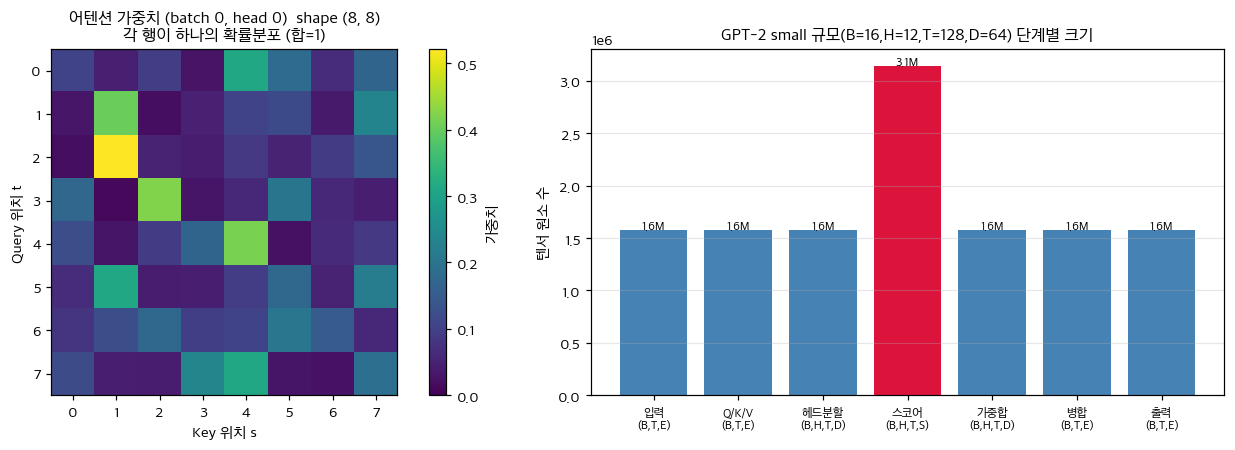

각 Query 행의 가중치 합: [1. 1. 1. 1. 1. 1. 1. 1.]  <- 모두 1
가중치 범위: 0.0114 ~ 0.5213

주목: 스코어 텐서는 (B,H,T,T) 라서 시퀀스 길이 T의 '제곱'으로 커진다.
  T=  128: 스코어 원소 수 =        3.1M   <- 긴 컨텍스트가 비싼 이유
  T=  512: 스코어 원소 수 =       50.3M   <- 긴 컨텍스트가 비싼 이유
  T= 2048: 스코어 원소 수 =      805.3M   <- 긴 컨텍스트가 비싼 이유


In [21]:
# 그림용으로는 가중치 스케일을 키워 패턴이 보이게 한다
# (0.02 스케일이면 스코어가 거의 0이라 softmax가 균등분포에 가까워 그림이 밋밋하다)
rng_v = np.random.default_rng(5)
Bv, Hv, Tv, Dv = 2, 4, 8, 16
Qv = rng_v.standard_normal((Bv, Hv, Tv, Dv))
Kv = rng_v.standard_normal((Bv, Hv, Tv, Dv))
scores_v = np.einsum("bhtd,bhsd->bhts", Qv, Kv) / np.sqrt(Dv)
weights = softmax(scores_v, axis=-1)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))

im = ax[0].imshow(weights[0, 0], cmap="viridis", vmin=0)
ax[0].set_xlabel("Key 위치 s"); ax[0].set_ylabel("Query 위치 t")
ax[0].set_xticks(range(Tv)); ax[0].set_yticks(range(Tv))
ax[0].set_title("어텐션 가중치 (batch 0, head 0)  shape (8, 8)\n각 행이 하나의 확률분포 (합=1)", fontsize=11)
plt.colorbar(im, ax=ax[0], label="가중치")

stages = ["입력\n(B,T,E)", "Q/K/V\n(B,T,E)", "헤드분할\n(B,H,T,D)",
          "스코어\n(B,H,T,S)", "가중합\n(B,H,T,D)", "병합\n(B,T,E)", "출력\n(B,T,E)"]
B_, H_, T_, D_ = 16, 12, 128, 64
E_ = H_ * D_
sizes = [B_*T_*E_, B_*T_*E_, B_*H_*T_*D_, B_*H_*T_*T_, B_*H_*T_*D_, B_*T_*E_, B_*T_*E_]
bars = ax[1].bar(range(len(stages)), sizes, color=["steelblue"]*3 + ["crimson"] + ["steelblue"]*3)
ax[1].set_xticks(range(len(stages))); ax[1].set_xticklabels(stages, fontsize=8)
ax[1].set_ylabel("텐서 원소 수")
ax[1].set_title("GPT-2 small 규모(B=16,H=12,T=128,D=64) 단계별 크기", fontsize=11)
for b, s in zip(bars, sizes):
    ax[1].text(b.get_x() + b.get_width()/2, s, f"{s/1e6:.1f}M", ha="center", va="bottom", fontsize=8)
ax[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print("각 Query 행의 가중치 합:", np.round(weights[0, 0].sum(axis=-1), 6), " <- 모두 1")
print(f"가중치 범위: {weights[0,0].min():.4f} ~ {weights[0,0].max():.4f}")

print(f"\n주목: 스코어 텐서는 (B,H,T,T) 라서 시퀀스 길이 T의 '제곱'으로 커진다.")
for T_test in [128, 512, 2048]:
    print(f"  T={T_test:>5}: 스코어 원소 수 = {16*12*T_test*T_test/1e6:>10,.1f}M"
          f"   <- 긴 컨텍스트가 비싼 이유")

## 9️⃣ 🏭 Use It — 세 가지 세계 비교

### Scratch vs NumPy

| 연산 | Scratch (Tensor 클래스) | NumPy |
| --- | --- | --- |
| 생성 | `Tensor([[1,2],[3,4]])` | `np.array([[1,2],[3,4]])` |
| Reshape | `t.reshape((3,4))` | `a.reshape(3,4)` |
| Transpose | `t.transpose(0,1)` | `a.T` 또는 `a.transpose(0,1)` |
| Squeeze | `t.squeeze(0)` | `np.squeeze(a, 0)` |
| Sum | `t.sum(axis=0)` | `a.sum(axis=0)` |
| Einsum | N/A | `np.einsum("ij,jk->ik", a, b)` |

In [22]:
t = Tensor([[1, 2], [3, 4]])
n = np.array([[1, 2], [3, 4]])

print(f"{'연산':<16}{'Scratch':<28}{'NumPy':<20}{'일치'}")
print("-" * 74)
rows = [
    ("생성",      t.shape,                     n.shape),
    ("reshape",   t.reshape((4, 1)).shape,     n.reshape(4, 1).shape),
    ("transpose", t.transpose(0, 1).data,      n.T.ravel().tolist()),
    ("sum(0)",    t.sum(axis=0).data,          n.sum(axis=0).tolist()),
    ("sum(1)",    t.sum(axis=1).data,          n.sum(axis=1).tolist()),
    ("+ 스칼라",  (t * 2).data,                (n * 2).ravel().tolist()),
]
for name, s_val, n_val in rows:
    print(f"{name:<16}{str(s_val):<28}{str(n_val):<20}{list(np.ravel(s_val)) == list(np.ravel(n_val))}")

연산              Scratch                     NumPy               일치
--------------------------------------------------------------------------
생성              (2, 2)                      (2, 2)              True
reshape         (4, 1)                      (4, 1)              True
transpose       [1, 3, 2, 4]                [1, 3, 2, 4]        True
sum(0)          [4, 6]                      [4, 6]              True
sum(1)          [3, 7]                      [3, 7]              True
+ 스칼라           [2, 4, 6, 8]                [2, 4, 6, 8]        True


### Scratch vs PyTorch

```python
import torch

t = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)
t.shape             # torch.Size([2, 3])
t.stride()          # (3, 1)
t.is_contiguous()   # True

t.reshape(3, 2)
t.unsqueeze(0)                    # (1, 2, 3)
t.transpose(0, 1)                 # (3, 2), 비연속
t.transpose(0, 1).contiguous()    # 메모리 재배치

torch.einsum("ik,kj->ij", A, B)
```

> PyTorch가 더해 주는 것: **autograd, GPU 지원, 최적화된 BLAS 커널.**
> 하지만 **shape 의미론은 완전히 동일하다.** scratch 버전을 이해하면 PyTorch shape 에러가 읽힌다.

| Scratch / NumPy | PyTorch 대응 | 주의 |
| --- | --- | --- |
| `a.strides` (바이트) | `t.stride()` (**원소 단위**) | 단위가 다르다 |
| `a.flags['C_CONTIGUOUS']` | `t.is_contiguous()` | 동일 개념 |
| `a.reshape(...)` | `t.reshape(...)` | 필요하면 복사 |
| (해당 없음) | `t.view(...)` | **비연속이면 실패** |
| `np.ascontiguousarray(a)` | `t.contiguous()` | 복사 발생 |
| `a[None]` / `np.expand_dims` | `t.unsqueeze(0)` | 동일 |
| `np.einsum` | `torch.einsum` | 문법 동일 |

In [23]:
# torch 없이도 view/contiguous 문제를 NumPy로 재현할 수 있다
a = np.arange(12).reshape(3, 4)
aT = a.T                                # 비연속

print("aT 는 연속인가:", aT.flags["C_CONTIGUOUS"])
print("PyTorch였다면 aT.view(12) 는 RuntimeError를 낸다:")
print('  "view size is not compatible with input tensor\'s size and stride..."')

# NumPy는 조용히 복사해 준다 -> 성능은 손해, 에러는 없음
flat = aT.reshape(-1)
print("\nNumPy reshape는 성공하지만 복사가 일어난다. aT와 메모리 공유:",
      np.shares_memory(aT, flat), " <- False = 복사됨")

aT_c = np.ascontiguousarray(aT)          # PyTorch의 .contiguous()
print("\n먼저 contiguous로 만든 뒤 reshape하면 복사 없이 뷰가 된다:",
      np.shares_memory(aT_c, aT_c.reshape(-1)), " <- True = 같은 메모리")

print("\n[PyTorch stride 단위 주의]")
print("  NumPy a.strides =", a.strides, "(바이트)")
print("  PyTorch t.stride() 이면 =", tuple(s // a.itemsize for s in a.strides), "(원소 개수)")

aT 는 연속인가: False
PyTorch였다면 aT.view(12) 는 RuntimeError를 낸다:
  "view size is not compatible with input tensor's size and stride..."

NumPy reshape는 성공하지만 복사가 일어난다. aT와 메모리 공유: False  <- False = 복사됨

먼저 contiguous로 만든 뒤 reshape하면 복사 없이 뷰가 된다: True  <- True = 같은 메모리

[PyTorch stride 단위 주의]
  NumPy a.strides = (32, 8) (바이트)
  PyTorch t.stride() 이면 = (4, 1) (원소 개수)


### 모든 신경망 레이어는 결국 텐서 연산이다

| 연산 | 텐서 형태 | Einsum |
| --- | --- | --- |
| Linear 층 | `Y = X @ W.T + b` | `"bd,od->bo"` + bias |
| Attention QKV | `Q = X @ W_q` | `"btd,dh->bth"` |
| Attention 스코어 | `Q @ K.T / sqrt(d)` | `"bhtd,bhsd->bhts"` |
| Attention 출력 | `softmax(scores) @ V` | `"bhts,bhsd->bhtd"` |
| Batch norm | `(X - mu) / sigma * gamma` | 원소별 + 브로드캐스트 |
| Softmax | `exp(x) / sum(exp(x))` | 원소별 + 축소 |

In [24]:
rng = np.random.default_rng(0)
Bn, Dn, On = 4, 8, 5
X = rng.standard_normal((Bn, Dn))
W = rng.standard_normal((On, Dn))          # (out, in)
bvec = rng.standard_normal(On)

# 1) Linear
y_mm = X @ W.T + bvec
y_es = np.einsum("bd,od->bo", X, W) + bvec
print(f"Linear      : X{X.shape} @ W{W.shape}.T + b{bvec.shape} -> {y_mm.shape}"
      f"   einsum 일치: {np.allclose(y_mm, y_es)}")

# 2) Batch norm (원소별 + 브로드캐스트)
mu, var = X.mean(0), X.var(0)
gamma, beta = rng.standard_normal(Dn), rng.standard_normal(Dn)
bn = (X - mu) / np.sqrt(var + 1e-5) * gamma + beta
print(f"BatchNorm   : X{X.shape} 에 mu{mu.shape} 브로드캐스트 -> {bn.shape}"
      f"   정규화 후 평균≈0: {np.allclose(((X-mu)/np.sqrt(var+1e-5)).mean(0), 0, atol=1e-12)}")

# 3) Softmax (원소별 + 축소)
sm = softmax(y_mm, axis=-1)
print(f"Softmax     : {y_mm.shape} -> {sm.shape}   각 행 합=1: {np.allclose(sm.sum(-1), 1)}")

# 4) Attention QKV 투영
Xs = rng.standard_normal((2, 6, 12))
Wq = rng.standard_normal((12, 12))
Qp = np.einsum("btd,dh->bth", Xs, Wq)
print(f"QKV 투영    : {Xs.shape} x {Wq.shape} -> {Qp.shape}"
      f"   matmul 일치: {np.allclose(Qp, Xs @ Wq)}")

# 5) 어텐션 스코어 / 출력
Q4 = rng.standard_normal((2, 3, 6, 4)); K4 = rng.standard_normal((2, 3, 6, 4))
V4 = rng.standard_normal((2, 3, 6, 4))
sc = np.einsum("bhtd,bhsd->bhts", Q4, K4) / np.sqrt(4)
ao = np.einsum("bhts,bhsd->bhtd", softmax(sc, -1), V4)
print(f"Attn 스코어 : Q{Q4.shape} x K{K4.shape} -> {sc.shape}")
print(f"Attn 출력   : weights{sc.shape} x V{V4.shape} -> {ao.shape}")

Linear      : X(4, 8) @ W(5, 8).T + b(5,) -> (4, 5)   einsum 일치: True
BatchNorm   : X(4, 8) 에 mu(8,) 브로드캐스트 -> (4, 8)   정규화 후 평균≈0: True
Softmax     : (4, 5) -> (4, 5)   각 행 합=1: True
QKV 투영    : (2, 6, 12) x (12, 12) -> (2, 6, 12)   matmul 일치: True
Attn 스코어 : Q(2, 3, 6, 4) x K(2, 3, 6, 4) -> (2, 3, 6, 6)
Attn 출력   : weights(2, 3, 6, 6) x V(2, 3, 6, 4) -> (2, 3, 6, 4)


## 🔟 📝 연습문제

원문의 4문제를 모두 푼다.

1. **Easy — reshape 왕복.** shape `(2, 3, 4)` 텐서를 `(6, 4)` → `(24,)` → 다시 `(2, 3, 4)`로 reshape하라. 각 단계에서 flat 데이터를 출력해 **원소 순서가 보존되는지** 확인하라.
2. **Medium — 브로드캐스팅 구현.** `Tensor` 클래스에 크기 1인 축을 목표 shape으로 확장하는 `broadcast_to(shape)` 메서드를 추가하라. 그리고 `_elementwise_op`가 연산 전에 자동으로 브로드캐스트하도록 수정하라. `(3, 1)` 과 `(1, 4)` 가 `(3, 4)` 를 만드는지 테스트하라.
3. **Hard — einsum 밑바닥 구현.** `einsum(subscripts, *tensors)` 를 직접 만들어라. 최소한 내적(`i,i->`), 행렬곱(`ij,jk->ik`), 외적(`i,j->ij`), 전치(`ij->ji`) 를 지원해야 한다. 첨자 문자열을 파싱하고, 축약될 인덱스를 찾아, 모든 인덱스 조합을 순회하라. `np.einsum` 과 비교 검증하라.
4. **Hard — 어텐션 shape 추적기.** `batch_size`, `seq_len`, `embed_dim`, `num_heads` 를 받아 멀티헤드 어텐션의 **모든 단계 shape을 출력**하는 함수를 작성하라: 입력, Q/K/V 투영, 헤드 분할, 어텐션 스코어, softmax 가중치, 가중합, 헤드 병합, 출력 투영.

### 연습문제 1 — reshape 왕복

In [25]:
t = Tensor(list(range(24)), shape=(2, 3, 4))
print(f"시작    shape={t.shape}  strides={t.strides}")
print(f"        flat={t.data}")

steps = [(6, 4), (24,), (2, 3, 4)]
cur = t
for shp in steps:
    cur = cur.reshape(shp)
    print(f"\nreshape{shp}  shape={cur.shape}  strides={cur.strides}")
    print(f"        flat={cur.data}")

print("\n원소 순서가 끝까지 보존되었는가:", cur.data == t.data)
print("최종 텐서가 원본과 같은가:", cur.shape == t.shape and cur.data == t.data)
print("NumPy도 동일:", np.array_equal(cur.to_numpy(), np.arange(24).reshape(2, 3, 4)))

# 인덱싱까지 확인
print("\n같은 논리 인덱스가 같은 값을 가리키는가:")
for idx in [(0, 0, 0), (1, 1, 1), (1, 2, 3)]:
    print(f"  t{idx} = {t[idx]}   왕복 후 = {cur[idx]}   일치: {t[idx] == cur[idx]}")

시작    shape=(2, 3, 4)  strides=(12, 4, 1)
        flat=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

reshape(6, 4)  shape=(6, 4)  strides=(4, 1)
        flat=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

reshape(24,)  shape=(24,)  strides=(1,)
        flat=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

reshape(2, 3, 4)  shape=(2, 3, 4)  strides=(12, 4, 1)
        flat=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

원소 순서가 끝까지 보존되었는가: True
최종 텐서가 원본과 같은가: True
NumPy도 동일: True

같은 논리 인덱스가 같은 값을 가리키는가:
  t(0, 0, 0) = 0   왕복 후 = 0   일치: True
  t(1, 1, 1) = 17   왕복 후 = 17   일치: True
  t(1, 2, 3) = 23   왕복 후 = 23   일치: True


### 연습문제 2 — `broadcast_to` 구현 + 자동 브로드캐스트

In [26]:
def _broadcast_to(self, shape):
    shape = tuple(shape)
    if len(shape) < self.ndim:
        raise ValueError(f"{self._shape} 를 {shape} 로 브로드캐스트 불가 (축이 줄어듦)")

    # 왼쪽을 1로 패딩해 축 개수를 맞춘다
    padded = (1,) * (len(shape) - self.ndim) + self._shape
    for i, (src, dst) in enumerate(zip(padded, shape)):
        if src != dst and src != 1:
            raise ValueError(f"{self._shape} 를 {shape} 로 브로드캐스트 불가 (축 {i}: {src} vs {dst})")

    src_strides = Tensor._compute_strides(padded)
    # 크기 1인 축은 stride를 0으로 -> 제자리에서 반복 읽기 (NumPy와 같은 트릭)
    eff = tuple(0 if s == 1 else st for s, st in zip(padded, src_strides))

    out = []
    def rec(axis, flat_pos):
        if axis == len(shape):
            out.append(self._data[flat_pos])
            return
        for i in range(shape[axis]):
            rec(axis + 1, flat_pos + i * eff[axis])
    rec(0, 0)
    return Tensor(out, shape=shape)


def _broadcast_shapes(sa, sb):
    n = max(len(sa), len(sb))
    pa = (1,) * (n - len(sa)) + tuple(sa)
    pb = (1,) * (n - len(sb)) + tuple(sb)
    out = []
    for x, y in zip(pa, pb):
        if x != y and x != 1 and y != 1:
            raise ValueError(f"브로드캐스트 불가: {tuple(sa)} vs {tuple(sb)}")
        out.append(max(x, y))
    return tuple(out)


def _elementwise_op_bc(self, other, op):
    if isinstance(other, Tensor):
        target = _broadcast_shapes(self._shape, other._shape)
        x = self.broadcast_to(target)
        y = other.broadcast_to(target)
        return Tensor([op(p, q) for p, q in zip(x._data, y._data)], shape=target)
    return Tensor([op(v, other) for v in self._data], shape=self._shape)


Tensor.broadcast_to = _broadcast_to
Tensor.__add__ = lambda s, o: _elementwise_op_bc(s, o, lambda a, b: a + b)
Tensor.__sub__ = lambda s, o: _elementwise_op_bc(s, o, lambda a, b: a - b)
Tensor.__mul__ = lambda s, o: _elementwise_op_bc(s, o, lambda a, b: a * b)

# 요구된 테스트: (3,1) 과 (1,4) -> (3,4)
x = Tensor([[1], [2], [3]])          # (3,1)
y = Tensor([[10, 20, 30, 40]])       # (1,4)
z = x + y
print(f"{x.shape} + {y.shape} -> {z.shape}")
print(np.array(z.data).reshape(z.shape))
print("NumPy와 일치:", np.array_equal(z.to_numpy(),
      np.array([[1], [2], [3]]) + np.array([[10, 20, 30, 40]])))

print("\n[broadcast_to 단독 테스트]")
for src_shape, tgt in [((3, 1), (3, 4)), ((1, 4), (3, 4)), ((3,), (2, 3)), ((1,), (2, 2))]:
    src = Tensor(list(range(int(np.prod(src_shape)))), shape=src_shape)
    got = src.broadcast_to(tgt)
    want = np.broadcast_to(src.to_numpy(), tgt)
    print(f"  {str(src_shape):<8} -> {str(tgt):<8} 일치: {np.array_equal(got.to_numpy(), want)}")

print("\n[실패해야 하는 경우]")
try:
    Tensor(list(range(6)), shape=(3, 2)).broadcast_to((3, 4))
except ValueError as e:
    print("  (3,2) -> (3,4):", e)
try:
    Tensor([[1, 2, 3]]) + Tensor([[1, 2]])
except ValueError as e:
    print("  (1,3) + (1,2):", e)

print("\n[4D 실무 케이스] (2,3,4,4) * (1,3,1,1)")
img = Tensor(list(range(2*3*4*4)), shape=(2, 3, 4, 4))
sc  = Tensor([0, 1, 2], shape=(1, 3, 1, 1))
res = img * sc
print("  결과 shape:", res.shape, " NumPy와 일치:",
      np.array_equal(res.to_numpy(),
                     np.arange(96).reshape(2,3,4,4) * np.array([0,1,2]).reshape(1,3,1,1)))

(3, 1) + (1, 4) -> (3, 4)
[[11 21 31 41]
 [12 22 32 42]
 [13 23 33 43]]
NumPy와 일치: True

[broadcast_to 단독 테스트]
  (3, 1)   -> (3, 4)   일치: True
  (1, 4)   -> (3, 4)   일치: True
  (3,)     -> (2, 3)   일치: True
  (1,)     -> (2, 2)   일치: True

[실패해야 하는 경우]
  (3,2) -> (3,4): (3, 2) 를 (3, 4) 로 브로드캐스트 불가 (축 1: 2 vs 4)
  (1,3) + (1,2): 브로드캐스트 불가: (1, 3) vs (1, 2)

[4D 실무 케이스] (2,3,4,4) * (1,3,1,1)
  결과 shape: (2, 3, 4, 4)  NumPy와 일치: True


### 연습문제 3 — einsum 밑바닥 구현

In [27]:
from itertools import product


def my_einsum(subscripts, *tensors):
    # 1) 첨자 문자열 파싱
    subscripts = subscripts.replace(" ", "")
    if "->" in subscripts:
        lhs, out_spec = subscripts.split("->")
    else:
        lhs = subscripts
        counts = {}
        for ch in lhs.replace(",", ""):
            counts[ch] = counts.get(ch, 0) + 1
        out_spec = "".join(sorted(c for c, n in counts.items() if n == 1))   # 암묵 출력
    in_specs = lhs.split(",")

    arrs = [np.asarray(t) for t in tensors]
    if len(in_specs) != len(arrs):
        raise ValueError("첨자 개수와 텐서 개수가 다르다")

    # 2) 각 인덱스 글자의 크기를 확정 (동시에 일관성 검사)
    dim = {}
    for spec, arr in zip(in_specs, arrs):
        if len(spec) != arr.ndim:
            raise ValueError(f"'{spec}' 는 {len(spec)}축인데 텐서는 {arr.ndim}축")
        for ch, n in zip(spec, arr.shape):
            if ch in dim and dim[ch] != n:
                raise ValueError(f"인덱스 '{ch}' 크기 불일치: {dim[ch]} vs {n}")
            dim[ch] = n

    # 3) 출력에 없는 글자 = 축약(합산)될 인덱스
    all_idx = sorted(dim)
    sum_idx = [c for c in all_idx if c not in out_spec]

    out_shape = tuple(dim[c] for c in out_spec)
    out = np.zeros(out_shape if out_shape else ())

    # 4) 모든 인덱스 조합을 순회하며 곱하고 더한다
    for out_vals in product(*[range(dim[c]) for c in out_spec]):
        pos = dict(zip(out_spec, out_vals))
        total = 0.0
        for sum_vals in product(*[range(dim[c]) for c in sum_idx]):
            pos.update(zip(sum_idx, sum_vals))
            term = 1.0
            for spec, arr in zip(in_specs, arrs):
                term *= arr[tuple(pos[ch] for ch in spec)]
            total += term
        if out_shape:
            out[out_vals] = total
        else:
            out = np.asarray(total)
    return out


a = np.array([1.0, 2.0, 3.0])
b = np.array([4.0, 5.0, 6.0])
A = np.array([[1., 2.], [3., 4.], [5., 6.]])
Bm = np.array([[7., 8., 9.], [10., 11., 12.]])
Sq = np.array([[1., 2.], [3., 4.]])

tests = [
    ("i,i->",      (a, b),    "내적"),
    ("ij,jk->ik",  (A, Bm),   "행렬곱"),
    ("i,j->ij",    (a, b),    "외적"),
    ("ij->ji",     (A,),      "전치"),
    ("ii->",       (Sq,),     "대각합"),
    ("ij->i",      (A,),      "행 합"),
    ("ij->",       (A,),      "전체 합"),
    ("ij,j->i",    (Bm, a),   "행렬 x 벡터"),
]
print(f"{'표현식':<14}{'설명':<14}{'내 결과 shape':<18}{'np.einsum 일치'}")
print("-" * 66)
for expr, args, desc in tests:
    mine = my_einsum(expr, *args)
    ref  = np.einsum(expr, *args)
    print(f"{expr:<14}{desc:<14}{str(np.shape(mine)):<18}{np.allclose(mine, ref)}")

# 배치 행렬곱까지 되는지 (구현이 일반적이므로 동작해야 함)
ba = np.random.randn(3, 2, 4); bb = np.random.randn(3, 4, 5)
print(f"\n{'bij,bjk->bik':<14}{'배치 행렬곱':<14}{str(my_einsum('bij,bjk->bik', ba, bb).shape):<18}"
      f"{np.allclose(my_einsum('bij,bjk->bik', ba, bb), np.einsum('bij,bjk->bik', ba, bb))}")

# 암묵 출력(-> 생략)도 처리되는지
print(f"{'ij,jk (암묵)':<14}{'출력 생략':<14}{str(my_einsum('ij,jk', A, Bm).shape):<18}"
      f"{np.allclose(my_einsum('ij,jk', A, Bm), np.einsum('ij,jk', A, Bm))}")

print("\n[에러 검출]")
try:
    my_einsum("ij,jk->ik", A, A)      # (3,2) x (3,2): j가 2 vs 3
except ValueError as e:
    print("  ", e)

표현식           설명            내 결과 shape        np.einsum 일치
------------------------------------------------------------------
i,i->         내적            ()                True
ij,jk->ik     행렬곱           (3, 3)            True
i,j->ij       외적            (3, 3)            True
ij->ji        전치            (2, 3)            True
ii->          대각합           ()                True
ij->i         행 합           (3,)              True
ij->          전체 합          ()                True
ij,j->i       행렬 x 벡터       (2,)              True

bij,bjk->bik  배치 행렬곱        (3, 2, 5)         True
ij,jk (암묵)    출력 생략         (3, 3)            True

[에러 검출]
   인덱스 'j' 크기 불일치: 2 vs 3


### 연습문제 4 — 어텐션 shape 추적기

In [28]:
def attention_shape_tracker(batch_size, seq_len, embed_dim, num_heads):
    if embed_dim % num_heads != 0:
        raise ValueError(f"embed_dim({embed_dim})이 num_heads({num_heads})로 나누어떨어져야 한다")
    B, T, E, H = batch_size, seq_len, embed_dim, num_heads
    D = E // H

    steps = [
        ("입력 X",           (B, T, E),    "-",                              "토큰 임베딩"),
        ("Q/K/V 투영",       (B, T, E),    'einsum "bte,ek->btk"',           "각각 W_q/W_k/W_v (E,E)"),
        ("헤드 분할",        (B, H, T, D), "reshape(B,T,H,D)+transpose(0,2,1,3)", f"E={E} 를 H={H} x D={D} 로"),
        ("어텐션 스코어",    (B, H, T, T), 'einsum "bhtd,bhsd->bhts" /√D',   "T x T 라 T의 제곱으로 커짐"),
        ("softmax 가중치",   (B, H, T, T), "softmax(axis=-1)",               "각 행의 합 = 1"),
        ("가중합",           (B, H, T, D), 'einsum "bhts,bhsd->bhtd"',       "V를 가중 평균"),
        ("헤드 병합",        (B, T, E),    "transpose(0,2,1,3)+reshape",     f"H x D = {E} 로 복귀"),
        ("출력 투영",        (B, T, E),    'einsum "bte,ek->btk"',           "W_o (E,E)"),
    ]

    print(f"멀티헤드 어텐션 shape 추적")
    print(f"  batch={B}, seq_len={T}, embed_dim={E}, num_heads={H}  ->  head_dim={D}")
    print("=" * 112)
    print(f"  {'단계':<16}{'shape':>18}{'원소 수':>14}   {'연산':<38}{'메모'}")
    print("-" * 112)
    for name, shp, op, note in steps:
        print(f"  {name:<16}{str(shp):>18}{int(np.prod(shp)):>14,}   {op:<38}{note}")
    print("=" * 112)
    print(f"  입력 shape == 출력 shape : {steps[0][1] == steps[-1][1]}  (레이어를 쌓을 수 있는 이유)")
    peak = max(int(np.prod(s)) for _, s, _, _ in steps)
    print(f"  최대 텐서 크기: {peak:,} 원소 (float32 기준 {peak*4/1e6:.3f} MB)")
    return [s for _, s, _, _ in steps]


shapes = attention_shape_tracker(batch_size=2, seq_len=8, embed_dim=64, num_heads=4)

# demo_attention_einsum() 실제 실행 결과와 대조
print("\n[실제 실행값과 대조]")
_, w_check = multi_head_attention(B=2, H=4, T=8, D=16, verbose=False)
print(f"  추적기가 예측한 스코어 shape : {shapes[3]}")
print(f"  실제 weights.shape           : {w_check.shape}")
print(f"  일치: {shapes[3] == w_check.shape}")

print()
attention_shape_tracker(batch_size=16, seq_len=128, embed_dim=768, num_heads=12)

print("\n[나누어떨어지지 않는 경우]")
try:
    attention_shape_tracker(2, 8, 100, 12)
except ValueError as e:
    print("  ", e)

멀티헤드 어텐션 shape 추적
  batch=2, seq_len=8, embed_dim=64, num_heads=4  ->  head_dim=16
  단계                           shape          원소 수   연산                                    메모
----------------------------------------------------------------------------------------------------------------
  입력 X                    (2, 8, 64)         1,024   -                                     토큰 임베딩
  Q/K/V 투영                (2, 8, 64)         1,024   einsum "bte,ek->btk"                  각각 W_q/W_k/W_v (E,E)
  헤드 분할                (2, 4, 8, 16)         1,024   reshape(B,T,H,D)+transpose(0,2,1,3)   E=64 를 H=4 x D=16 로
  어텐션 스코어               (2, 4, 8, 8)           512   einsum "bhtd,bhsd->bhts" /√D          T x T 라 T의 제곱으로 커짐
  softmax 가중치           (2, 4, 8, 8)           512   softmax(axis=-1)                      각 행의 합 = 1
  가중합                  (2, 4, 8, 16)         1,024   einsum "bhts,bhsd->bhtd"              V를 가중 평균
  헤드 병합                   (2, 8, 64)         1,024   transpose(0,2,1,3)+resha

## 1️⃣1️⃣ 📚 용어 사전 (Key Terms)

| 용어 | 사람들이 말하는 것 | 실제 의미 |
| --- | --- | --- |
| **Tensor (텐서)** | "차원이 더 많은 행렬" | 자료형이 균일하고 shape·strides·연산이 정의된 다차원 배열 |
| **Rank (계수/차수)** | "차원의 개수" | **축의 개수.** 행렬은 언제나 rank 2다 — 그 행렬의 선형대수적 rank와는 무관 |
| **Shape (모양)** | "텐서의 크기" | 각 축의 크기를 나열한 튜플. `(2, 3)` = 2행 3열 |
| **Stride (스트라이드)** | "메모리에 어떻게 놓였나" | 각 축에서 **한 칸 이동할 때 건너뛸 원소 수** |
| **Broadcasting** | "모양 달라도 알아서 되던데" | 엄격한 규칙: 오른쪽부터 정렬, 각 축은 같거나 한쪽이 1이어야 함 |
| **Contiguous (연속)** | "텐서가 정상이다" | 논리적 배치 그대로 메모리에 빈틈·재정렬 없이 순차 저장된 상태 |
| **Einsum** | "matmul 멋있게 쓰는 법" | 임의의 텐서 축약·외적·대각합·전치를 한 줄로 표현하는 일반 표기법 |
| **View (뷰)** | "reshape이랑 같은 거" | **같은 메모리 버퍼**를 공유하고 shape/stride 메타데이터만 다른 텐서. **비연속 데이터에서는 실패** |
| **Contraction (축약)** | "인덱스로 합치기" | 텐서 사이의 공유 인덱스를 곱하고 합해 rank를 낮추는 일반 연산 |
| **NCHW / NHWC** | "PyTorch냐 TensorFlow냐" | 이미지 텐서의 메모리 레이아웃 관례. NCHW는 채널을 공간축 앞에, NHWC는 뒤에 둔다 |

In [29]:
# 용어를 한 번에 확인하는 요약 코드
x = np.arange(24, dtype=np.float32).reshape(2, 3, 4)
print(f"Tensor       : {x.__class__.__name__}, dtype={x.dtype}")
print(f"Rank         : {x.ndim}   (축 개수)")
print(f"Shape        : {x.shape}  (원소 {x.size}개)")
print(f"Stride(바이트): {x.strides}  / 원소 단위: {tuple(s//x.itemsize for s in x.strides)}")
print(f"Contiguous   : {x.flags['C_CONTIGUOUS']}")

v = x.transpose(1, 0, 2)
print(f"\nView(전치)    : shape {v.shape}, 메모리 공유 {np.shares_memory(x, v)}, "
      f"contiguous {v.flags['C_CONTIGUOUS']}")

base = np.arange(4.)
bc = np.broadcast_to(base, (2, 3, 4))
print(f"Broadcasting : (4,) -> {bc.shape}, 원본과 메모리 공유 {np.shares_memory(base, bc)}, "
      f"strides {bc.strides} <- 0인 축은 제자리 반복 읽기")

con = np.einsum("ijk,ijk->i", x, x)
print(f"Contraction  : 'ijk,ijk->i'  {x.shape} -> {con.shape}  (j,k 축이 합쳐져 사라짐)")

nchw = np.zeros((8, 3, 32, 32)); nhwc = nchw.transpose(0, 2, 3, 1)
print(f"NCHW/NHWC    : {nchw.shape} -> {nhwc.shape}")

Tensor       : ndarray, dtype=float32
Rank         : 3   (축 개수)
Shape        : (2, 3, 4)  (원소 24개)
Stride(바이트): (48, 16, 4)  / 원소 단위: (12, 4, 1)
Contiguous   : True

View(전치)    : shape (3, 2, 4), 메모리 공유 True, contiguous False
Broadcasting : (4,) -> (2, 3, 4), 원본과 메모리 공유 True, strides (0, 0, 8) <- 0인 축은 제자리 반복 읽기
Contraction  : 'ijk,ijk->i'  (2, 3, 4) -> (2,)  (j,k 축이 합쳐져 사라짐)
NCHW/NHWC    : (8, 3, 32, 32) -> (8, 32, 32, 3)


## 🚢 Use It / Ship It

원문에서 안내하는 실행 자산:

```bash
python tensors.py      # code/tensors.py — 전체 데모
```

**Ship It — 이 레슨이 만들어 내는 재사용 프롬프트 2개**

1. **`outputs/prompt-tensor-shapes.md`** — 텐서 shape 불일치를 체계적으로 디버깅하는 프롬프트.
   모든 흔한 연산(matmul, broadcast, cat, Linear, Conv2d, BatchNorm, softmax)의 **결정 표**와 **수정 조회 표**를 포함.
2. **`outputs/prompt-tensor-debugger.md`** — shape 에러에 막혔을 때 AI 어시스턴트에 붙여 넣는 단계별 디버깅 프롬프트.
   에러 메시지와 텐서 shape을 넣으면 정확한 수정을 받아 온다.

### 🛠️ shape 에러 즉효 처방전 (스터디용 정리)

| 증상 | 원인 | 처방 |
| --- | --- | --- |
| `mat1 and mat2 shapes cannot be multiplied (AxB and CxD)` | `B != C` | `W.T` 로 전치하거나 Linear의 `(out, in)` 순서 확인 |
| `Expected 4D input (got 3D input)` | 배치 축 없음 | `x.unsqueeze(0)` 또는 `x[None]` |
| `view size is not compatible ... stride` | transpose 후 비연속 | `.contiguous().view(...)` 또는 `.reshape(...)` |
| 에러 없이 loss가 이상함 | 브로드캐스팅 오작동 | `(N,)` vs `(N,1)` 확인, `target.view(-1)` |
| 정확도가 안 오름 | 축소 축 실수 | `sum/mean`의 `axis` 와 `keepdims` 확인 |
| CPU/GPU가 느림 | 레이아웃 불일치 | NCHW/NHWC 통일, 불필요한 `.contiguous()` 제거 |
| OOM (메모리 부족) | 어텐션 `(B,H,T,T)` | `T`를 줄이거나 flash-attention 계열 사용 |

## 📖 더 읽을거리 (Further Reading)

- [NumPy Broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html) — 규칙의 정본, 시각 예제 포함
- [PyTorch Tensor Views](https://pytorch.org/docs/stable/tensor_view.html) — view가 되는 경우와 복사가 일어나는 경우
- [einops](https://github.com/arogozhnikov/einops) — 텐서 reshape을 읽기 쉽고 안전하게 만드는 라이브러리
- [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/) — 어텐션을 흐르는 텐서 shape의 시각화
- [Einstein Summation in NumPy](https://numpy.org/doc/stable/reference/generated/numpy.einsum.html) — einsum 전체 문서와 예제

---

## 🎯 한 문장 정리

> **텐서 = 서랍장. shape은 "몇 칸씩 나뉘었나", strides는 "한 칸 옮기려면 몇 개 건너뛰나".**
> transpose는 **데이터를 옮기지 않고 건너뛰는 규칙만 바꾸며**, 그래서 비연속이 된다.
> 브로드캐스팅은 **크기 1인 축을 복사 없이 늘리는 것**이고, einsum은 **축에 이름을 붙여 "짝짓고 합치는" 만능 표기법**이다.

| 개념 | 한 줄 요약 |
| --- | --- |
| rank / shape | 축의 개수 / 각 축의 크기. 행렬의 rank와 헷갈리지 말 것 |
| strides | 축을 한 칸 옮길 때 건너뛸 원소 수. `flat = Σ idx[i]·stride[i]` |
| transpose | strides만 스왑 → **비연속** → PyTorch `view` 실패 |
| broadcasting | 오른쪽 정렬 → 같거나 한쪽이 1 → 왼쪽은 1로 패딩 |
| einsum | 출력에 없는 글자로 합산. `ik,kj->ij` 가 곧 행렬곱 |
| 축약 비용 | 등장하는 모든 인덱스 크기의 곱 |
| 어텐션 | 투영 → 헤드분할 → 스코어 → softmax → 가중합 → 병합 → 투영 |
| 어텐션 메모리 | 스코어가 `(B,H,T,T)` — **T의 제곱**으로 커진다 |
| DL 관례 | Vision `(B,C,H,W)` / NLP `(B,T,D)` / Attention `(B,H,T,D)` |